In [1]:
import os
import sys
import shutil
import math
import warnings
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import *
from enum import Enum
from scipy.spatial import Voronoi
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import LabelEncoder
from scipy.stats import wasserstein_distance
sys.path.append("/home/esraan/CellDeathSpreading/")
from src.utils import get_experiment_cell_death_times_by_specific_siliding_window,read_experiment_cell_xy_and_death_times
from src.NucleationAndPropagationMeasurements import replace_ugly_long_name
from src.quanta_utils import get_neighbors
from src.DeathQuanta import DeathQuanta
from src.NucleationAndPropagationMeasurements import *
import seaborn as sns
from src.uSpiCalc import uSpiCalc
from src.mSpiCalc import mSpiCalc
from src.mixSpiCalc import mixSpiCalc

## Sensitivity analysis

In [2]:

def simple_treatment(name):
    # if "field" in name.lower():
    #     return "FB"
    if "nec" in name.lower():
        return "NecrosisInColonies"
    elif "apop" in name.lower():
        return "ApoptosisInColonies"
    else:
        if "_A" in name:
            return "MixedSubApop"
        elif "_N" in name:
            return "MixedSubNec"
        return "MixedColony"

In [ ]:
exps_dir_name = "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns"
meta_data_file_full_path= "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/all_csv_files_minutes_microns_with_sytox.csv"# "/sise/assafzar-group/assafzar/Esraa/Others/UpdatedMetaData.csv"
meta_data_extract_exp_names= pd.read_csv(meta_data_file_full_path)
exp_names = meta_data_extract_exp_names.iloc[:,1]
all_previous_experiments_spi_and_ni_regeneration = calc_all_experiments_SPI_and_NI_for_landscape(list(exp_names),exps_dir_path=exps_dir_name,
                                                                                                 meta_data_full_file_path=meta_data_file_full_path,
                                                                                                 dist_threshold=100,
                                                                                                 filter_neighbors_by_distance = 1,
                                                                                                 filter_neighbors_by_level = 1,)
reformatting_all_previos_experiments_spi_and_ni_regeneration = {"Experiment_name":[],
                                                                "SPI":[],
                                                                "NI":[],
                                                                "Treatment":[],
                                                                "Cell Line + Treatment":[],
                                                                "Cell Line":[],
                                                                "Origin":[],
                                                                "Mode":[],
                                                                "Density":[],
                                                                "pvalue":[]}
for key,value in all_previous_experiments_spi_and_ni_regeneration.items():
    if value is None or "--19" in key or "mixed" in simple_treatment(key):
        continue
    origin = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == key]["Origin"].values[0]
    mode = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == key]["Mode"].values[0]
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Origin"].append(origin)
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Mode"].append(mode)
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Experiment_name"].append(key)
    exp_cell_line= meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"]== key]["Cell Line"].values[0]
    reformatting_all_previos_experiments_spi_and_ni_regeneration["SPI"].append(value[0])
    reformatting_all_previos_experiments_spi_and_ni_regeneration["NI"].append(value[1])
    reformatting_all_previos_experiments_spi_and_ni_regeneration["pvalue"].append(value[2])
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Cell Line"].append(exp_cell_line)
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Cell Line + Treatment"].append(replace_ugly_long_name(key,exp_cell_line))
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Treatment"].append(simple_treatment(key))
    density = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == key]["Density(#Cells)"].values[0]
    reformatting_all_previos_experiments_spi_and_ni_regeneration["Density"].append(density)

In [20]:
only_recent_death_flag_for_neighbors_calc = False
# sliding_time_window_size = 20
exps_dir_name = "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns"
meta_data_file_full_path = "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/all_csv_files_minutes_microns_with_sytox.csv"
meta_data_extract_exp_names = pd.read_csv(meta_data_file_full_path)
exp_names = meta_data_extract_exp_names.iloc[:, 1]
meta_data_df = pd.read_csv(meta_data_file_full_path)

final_dataframe = pd.DataFrame()

for neighbors_dist_threshold in (33, 50, 100, 150, 200):
    for sliding_time_window_size in (5, 10, 30, 60, 90, 120):
        p_nucs_by_exp_name = {}
        global_density_by_exp_name = {}
        all_previous_experiments_spi_and_ni_regeneration = calc_all_experiments_SPI_and_NI_for_landscape(
            exp_name=list(exp_names),
            exps_dir_path=exps_dir_name,
            meta_data_full_file_path=meta_data_file_full_path,
            dist_threshold=neighbors_dist_threshold,
            only_recent_death_flag_for_neighbors_calc=only_recent_death_flag_for_neighbors_calc,
            time_unit="minutes",
            sliding_time_window_size=sliding_time_window_size
        )
        reformatting_all_previos_experiments_spi_and_ni_regeneration = {"Experiment_name": [],
                                                                        "SPI": [],
                                                                        "NI": [],
                                                                        "Treatment": [],
                                                                        "Cell Line + Treatment": [],
                                                                        "Cell Line": [],
                                                                        "Origin": [],
                                                                        "Mode": [],
                                                                        "Density": [],
                                                                        "pvalue": [],
                                                                        "sliding_time_window_size": [],
                                                                        "neighbors_dist_threshold": []}
        for key, value in all_previous_experiments_spi_and_ni_regeneration.items():
            if value is None:
                continue
            origin = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == key]["Origin"].values[0]
            mode = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == key]["Mode"].values[0]
            reformatting_all_previos_experiments_spi_and_ni_regeneration["Origin"].append(origin)
            reformatting_all_previos_experiments_spi_and_ni_regeneration["Mode"].append(mode)
            reformatting_all_previos_experiments_spi_and_ni_regeneration["Experiment_name"].append(key)
            exp_cell_line = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == key]["Cell Line"].values[0]
            reformatting_all_previos_experiments_spi_and_ni_regeneration["SPI"].append(value[0])
            reformatting_all_previos_experiments_spi_and_ni_regeneration["NI"].append(value[1])
            reformatting_all_previos_experiments_spi_and_ni_regeneration["pvalue"].append(value[2])
            reformatting_all_previos_experiments_spi_and_ni_regeneration["Cell Line"].append(exp_cell_line)
            reformatting_all_previos_experiments_spi_and_ni_regeneration["Cell Line + Treatment"].append(replace_ugly_long_name(key, exp_cell_line))
            reformatting_all_previos_experiments_spi_and_ni_regeneration["Treatment"].append(simple_treatment(key))
            density = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == key]["Density(#Cells)"].values[0]
            reformatting_all_previos_experiments_spi_and_ni_regeneration["Density"].append(density)
            reformatting_all_previos_experiments_spi_and_ni_regeneration["sliding_time_window_size"].append(sliding_time_window_size)
            reformatting_all_previos_experiments_spi_and_ni_regeneration["neighbors_dist_threshold"].append(neighbors_dist_threshold)
        
        reformatting_all_previos_experiments_spi_and_ni_regeneration_df = pd.DataFrame(reformatting_all_previos_experiments_spi_and_ni_regeneration)
        merged_df = reformatting_all_previos_experiments_spi_and_ni_regeneration_df[reformatting_all_previos_experiments_spi_and_ni_regeneration_df["Origin"] != 'field3_colony']
        # merged_df['segregationIndex'] = merged_df.apply(
        #     lambda row: plot_res_dict.get(row['Origin'], {}).get(row['Mode'].lower(), None),
        #     axis=1
        # )
        final_dataframe = pd.concat([final_dataframe, merged_df], ignore_index=True)

/home/esraan/CellDeathSpreading/src/uSpiCalc.py:26: RuntimeWarning: divide by zero encountered in scalar divide
  self.propagation_index = ((self.scramble_signficance_95 - self.original_difference_death_times) / self.scramble_signficance_95)
/home/esraan/CellDeathSpreading/src/uSpiCalc.py:26: RuntimeWarning: divide by zero encountered in scalar divide
  self.propagation_index = ((self.scramble_signficance_95 - self.original_difference_death_times) / self.scramble_signficance_95)
/home/esraan/CellDeathSpreading/src/uSpiCalc.py:26: RuntimeWarning: divide by zero encountered in scalar divide
  self.propagation_index = ((self.scramble_signficance_95 - self.original_difference_death_times) / self.scramble_signficance_95)
/home/esraan/CellDeathSpreading/src/uSpiCalc.py:26: RuntimeWarning: divide by zero encountered in scalar divide
  self.propagation_index = ((self.scramble_signficance_95 - self.original_difference_death_times) / self.scramble_signficance_95)
/home/esraan/CellDeathSpreading/

In [21]:
final_dataframe.to_csv("/home/esraan/CellDeathSpreading/results/AllExperimentsSPIandNIRegeneration.csv", index=False)

In [22]:
filtered_df = final_dataframe[
    ~final_dataframe['Experiment_name'].str.contains('pure|mix|SKT', case=False)
]

In [23]:
filtered_df.to_csv("/home/esraan/CellDeathSpreading/results/FilteredExperimentsSPIandNIRegeneration.csv", index=False)

In [2]:
filtered_df = pd.read_csv("/home/esraan/CellDeathSpreading/results/FilteredExperimentsSPIandNIRegeneration.csv")

### plot 1:

IndexError: index 5 is out of bounds for axis 1 with size 5

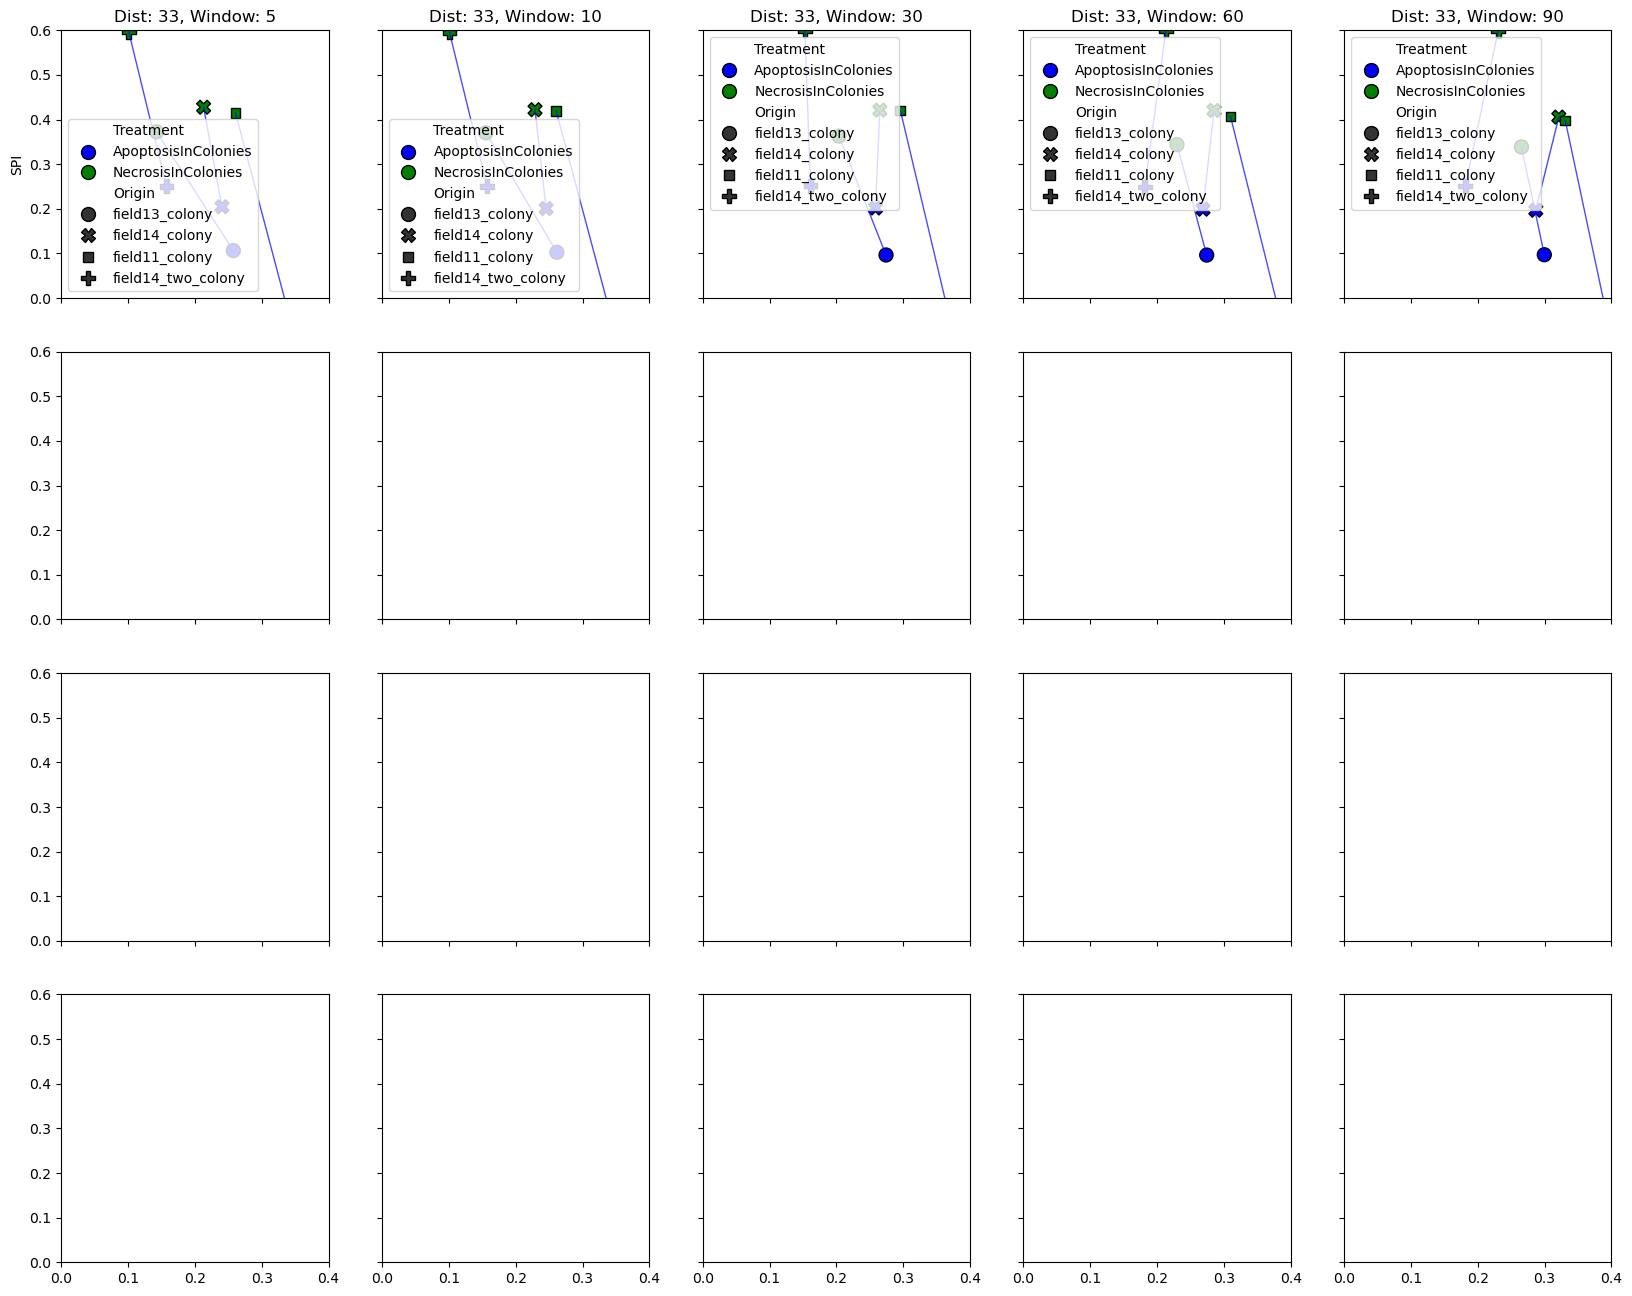

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the custom palette
custom_palette = {
    'ApoptosisInColonies': 'blue',
    'NecrosisInColonies': 'green'
}

# # Example scatterplot using the custom palette
# fig, ax = plt.subplots(figsize=(10, 6))

# sns.scatterplot(
#     data=merged_df,
#     x="NI",
#     y="SPI",
#     hue="Treatment",
#     style="Origin",
#     palette=custom_palette,
#     edgecolor="black",
#     linewidth=1,
#     s=150,
#     ax=ax
# )

# # Add connecting lines between points from the same origin
# for origin, group in merged_df.groupby("Origin"):
#     ax.plot(group["NI"], group["SPI"], linestyle='-', linewidth=1, alpha=0.7, color = 'b')

# # Customize labels and legend
# ax.set_xlabel("Nucleation Index (NI)")
# ax.set_ylabel("Spatial Propagation Index (SPI)")
# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
# ax.set_xlim(0, 0.4)
# ax.set_ylim(0, 0.6)

# plt.tight_layout()
# plt.show()
# Define the grid of subplots
fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(20, 16), sharex=True, sharey=True)

# Define the unique distances and sliding time windows
distances = filtered_df['neighbors_dist_threshold'].unique()
sliding_windows = filtered_df['sliding_time_window_size'].unique()

# Sort distances and sliding windows for consistent plotting
distances = sorted(distances)
sliding_windows = sorted(sliding_windows)

# Iterate over distances and sliding windows to create subplots
for i, dist in enumerate(distances):
    for j, window in enumerate(sliding_windows):
        ax = axes[i, j]
        subset = filtered_df[
            (filtered_df['neighbors_dist_threshold'] == dist) &
            (filtered_df['sliding_time_window_size'] == window)
        ]
        
        sns.scatterplot(
            data=subset,
            x="NI",
            y="SPI",
            hue="Treatment",
            style="Origin",
            palette=custom_palette,
            edgecolor="black",
            linewidth=1,
            s=100,
            ax=ax
        )
        
        # Add connecting lines between points from the same origin
        for origin, group in subset.groupby("Origin"):
            ax.plot(group["NI"], group["SPI"], linestyle='-', linewidth=1, alpha=0.7, color='b')
        
        # Set subplot title
        ax.set_title(f"Dist: {dist}, Window: {window}")
        ax.set_xlim(0, 0.4)
        ax.set_ylim(0, 0.6)

# Adjust layout and add a common legend
plt.tight_layout()
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', frameon=False)
plt.show()

### plot 2:

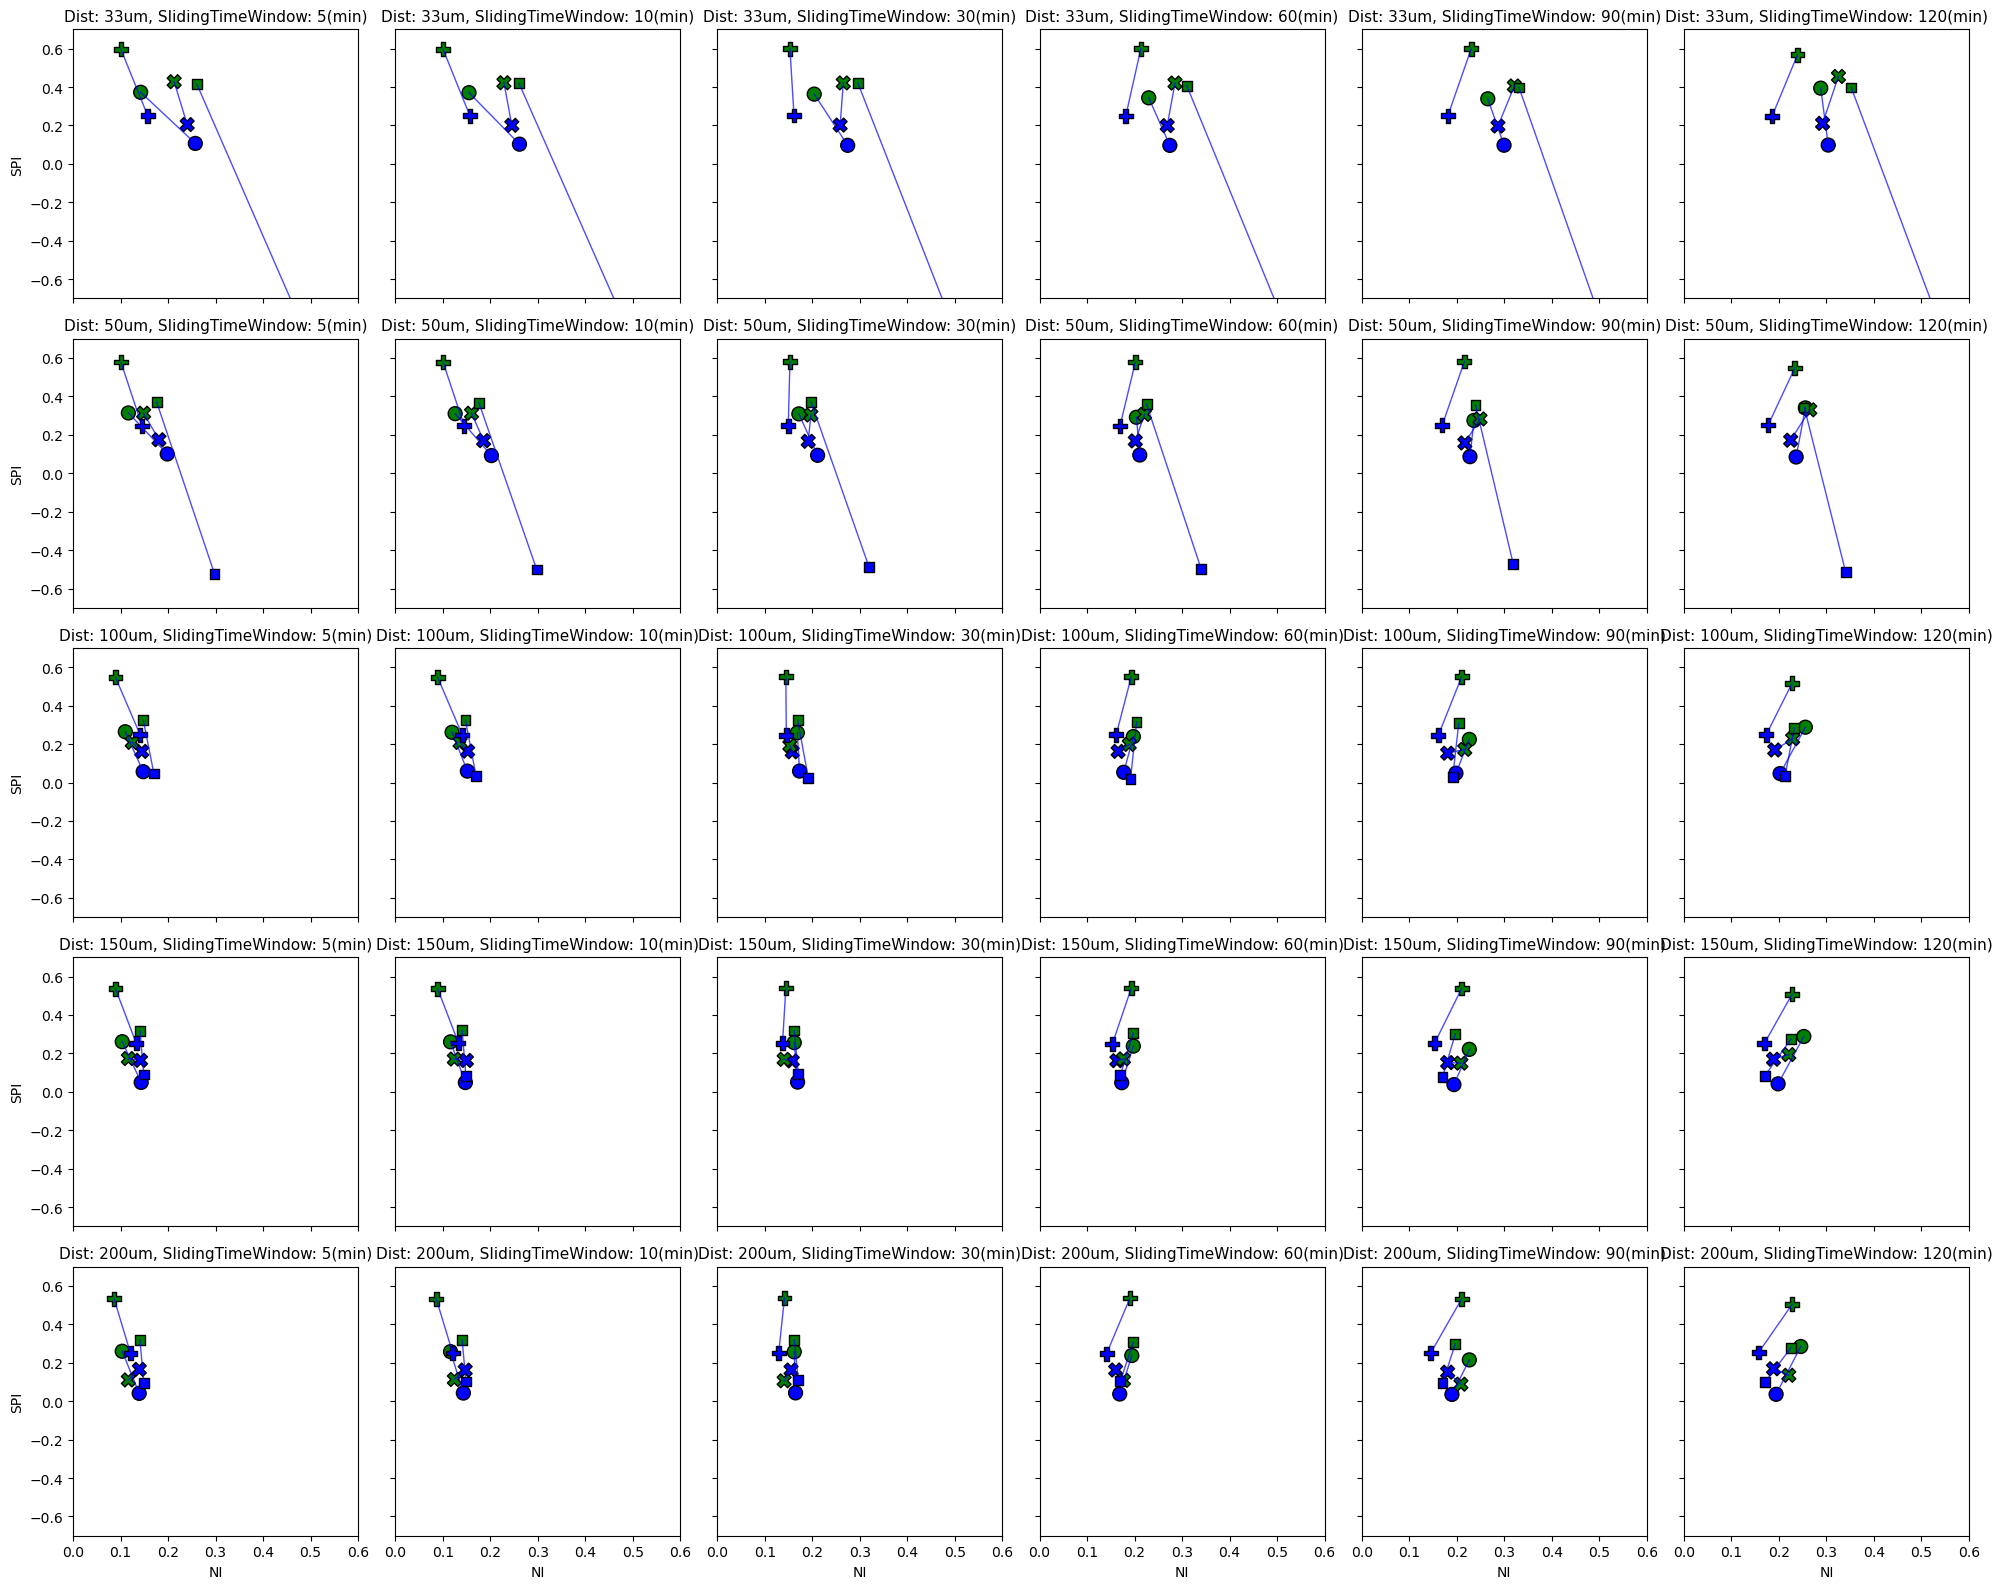

In [15]:
# Define the grid of subplots
# Define the custom palette
custom_palette = {
    'ApoptosisInColonies': 'blue',
    'NecrosisInColonies': 'green'
}
fig, axes = plt.subplots(nrows=5, ncols=6, figsize=(20, 16), sharex=True, sharey=True)

# Define the unique distances and sliding time windows
distances = filtered_df['neighbors_dist_threshold'].unique()
sliding_windows = filtered_df['sliding_time_window_size'].unique()

# Sort distances and sliding windows for consistent plotting
distances = sorted(distances)
sliding_windows = sorted(sliding_windows)

# Iterate over distances and sliding windows to create subplots
for i, dist in enumerate(distances):
    for j, window in enumerate(sliding_windows):
        ax = axes[i, j]
        subset = filtered_df[
            (filtered_df['neighbors_dist_threshold'] == dist) &
            (filtered_df['sliding_time_window_size'] == window)
        ]
        
        sns.scatterplot(
            data=subset,
            x="NI",
            y="SPI",
            hue="Treatment",
            style="Origin",
            palette=custom_palette,
            edgecolor="black",
            linewidth=1,
            s=100,
            ax=ax,
            legend=False  # Suppress legend for all subplots
        )
        
        # Add connecting lines between points from the same origin
        for origin, group in subset.groupby("Origin"):
            ax.plot(group["NI"], group["SPI"], linestyle='-', linewidth=1, alpha=0.7, color='b')
        
        # Set subplot title
        # ax.set_title(f"Dist: {dist}, Window: {window}")

        ax.set_title(f"Dist: {dist}um, SlidingTimeWindow: {window}(min)", fontsize = 11)
        ax.set_xlim(0, 0.6)
        ax.set_ylim(-0.7, 0.7)

# Add legend to the last subplot
handles, labels = axes[-1, -1].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', frameon=False)

# Adjust layout
plt.tight_layout()
plt.show()


### plot 3

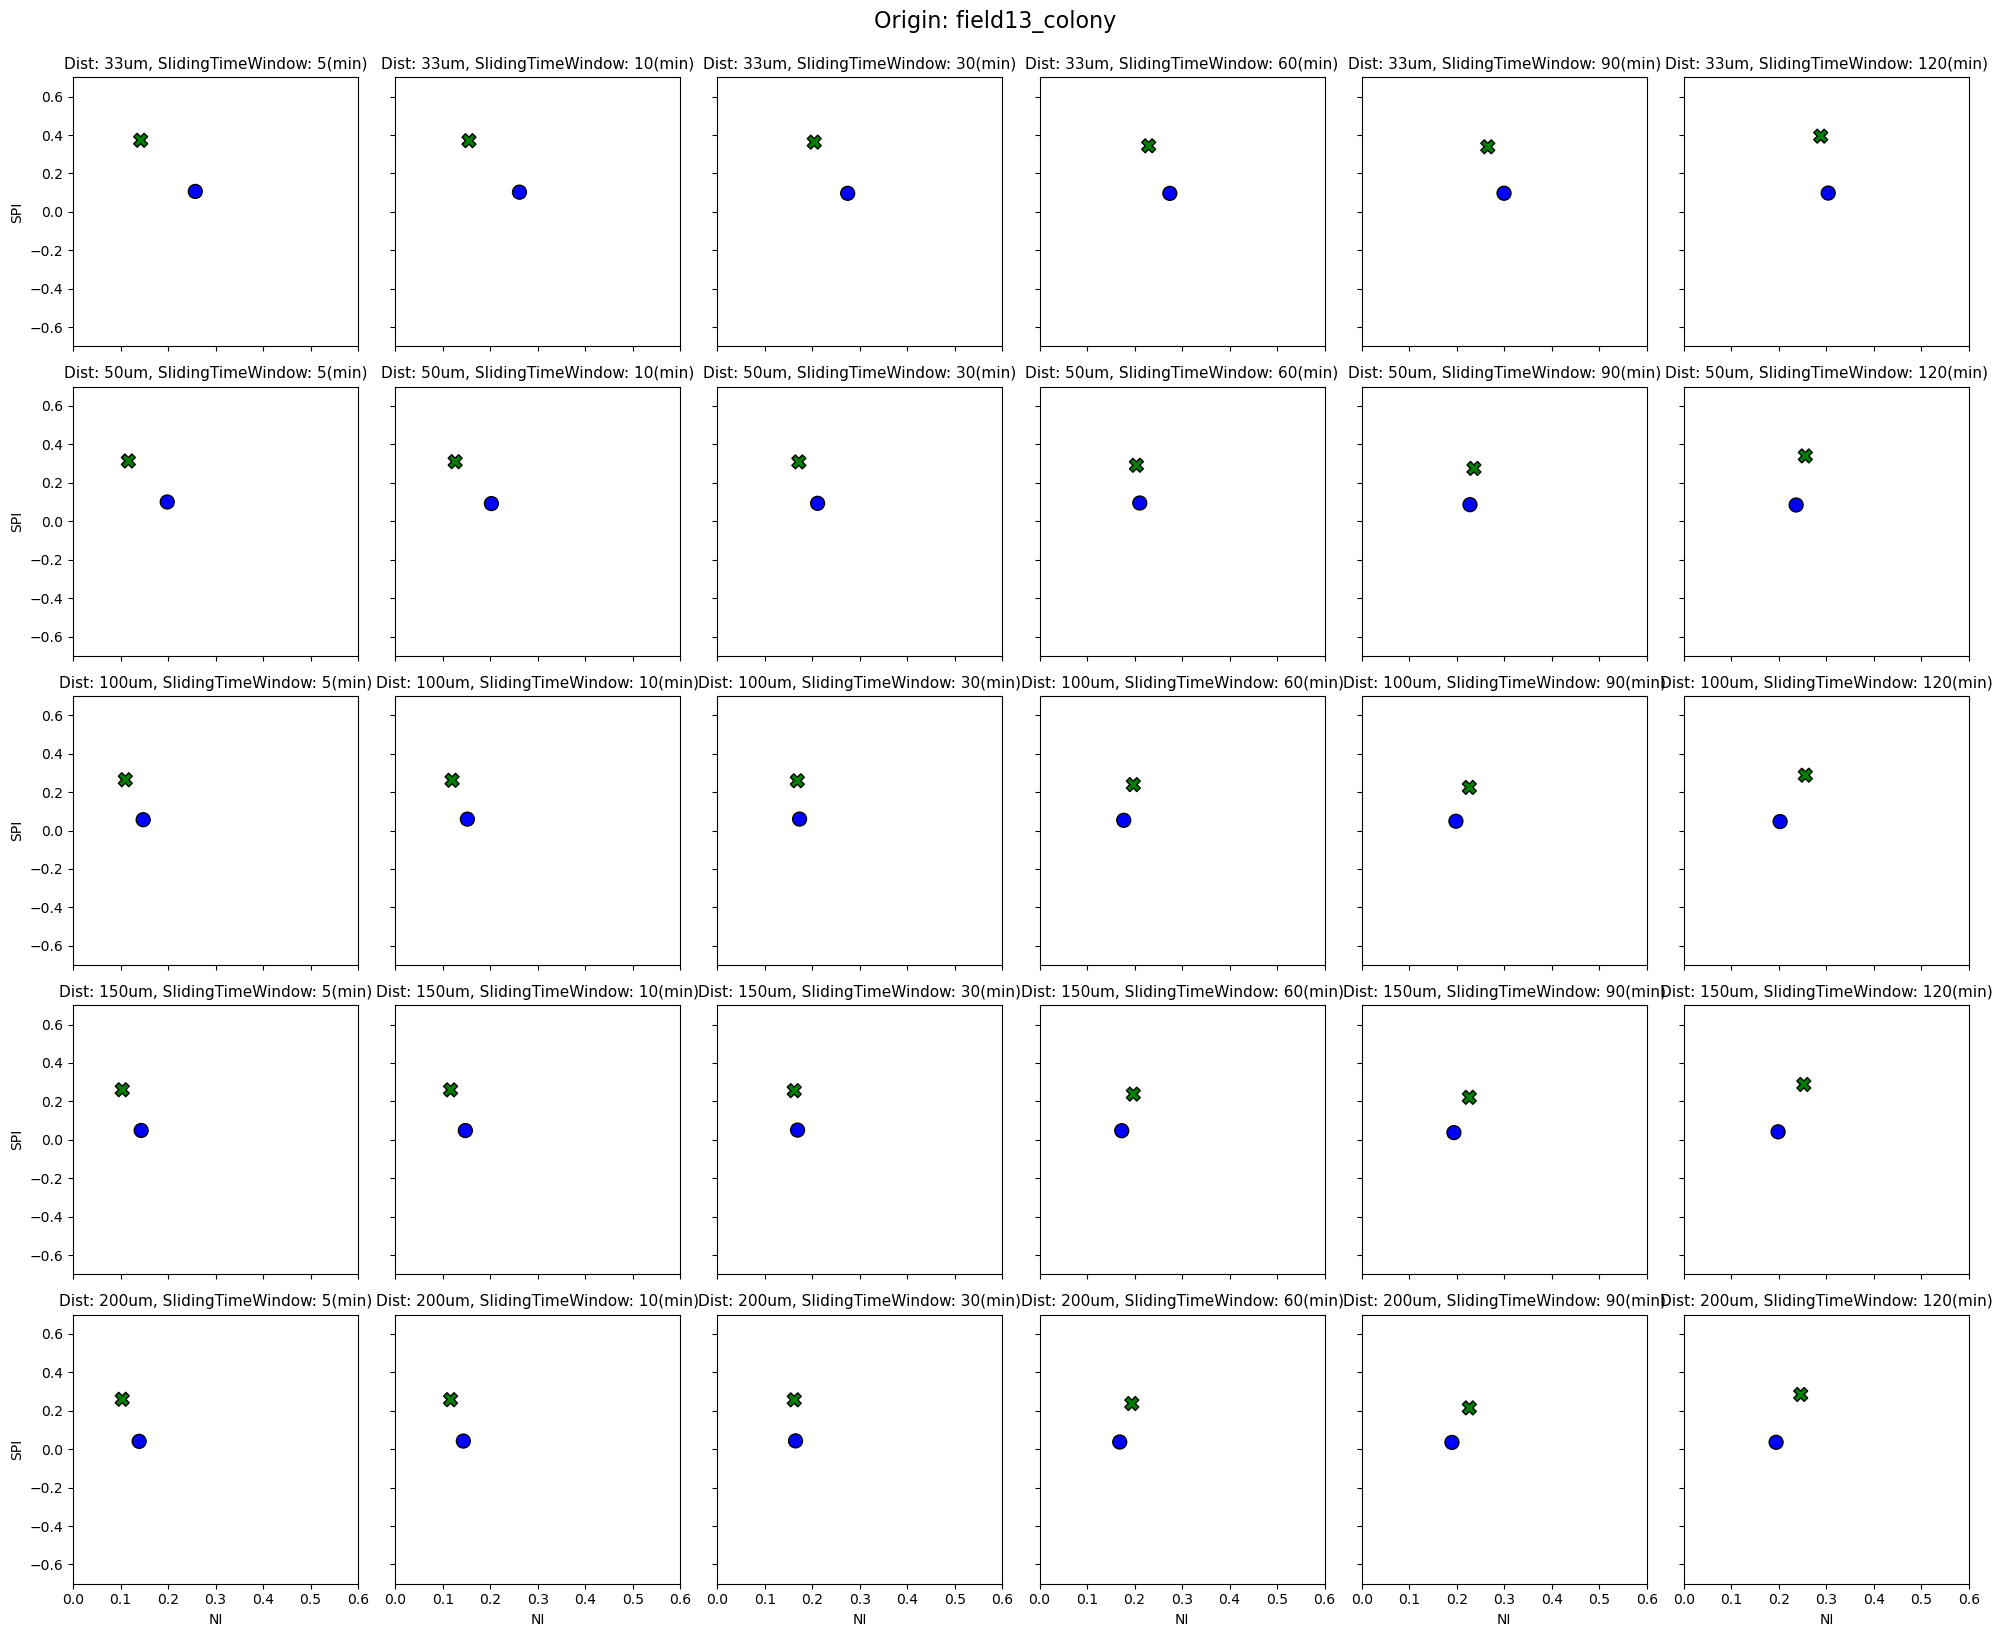

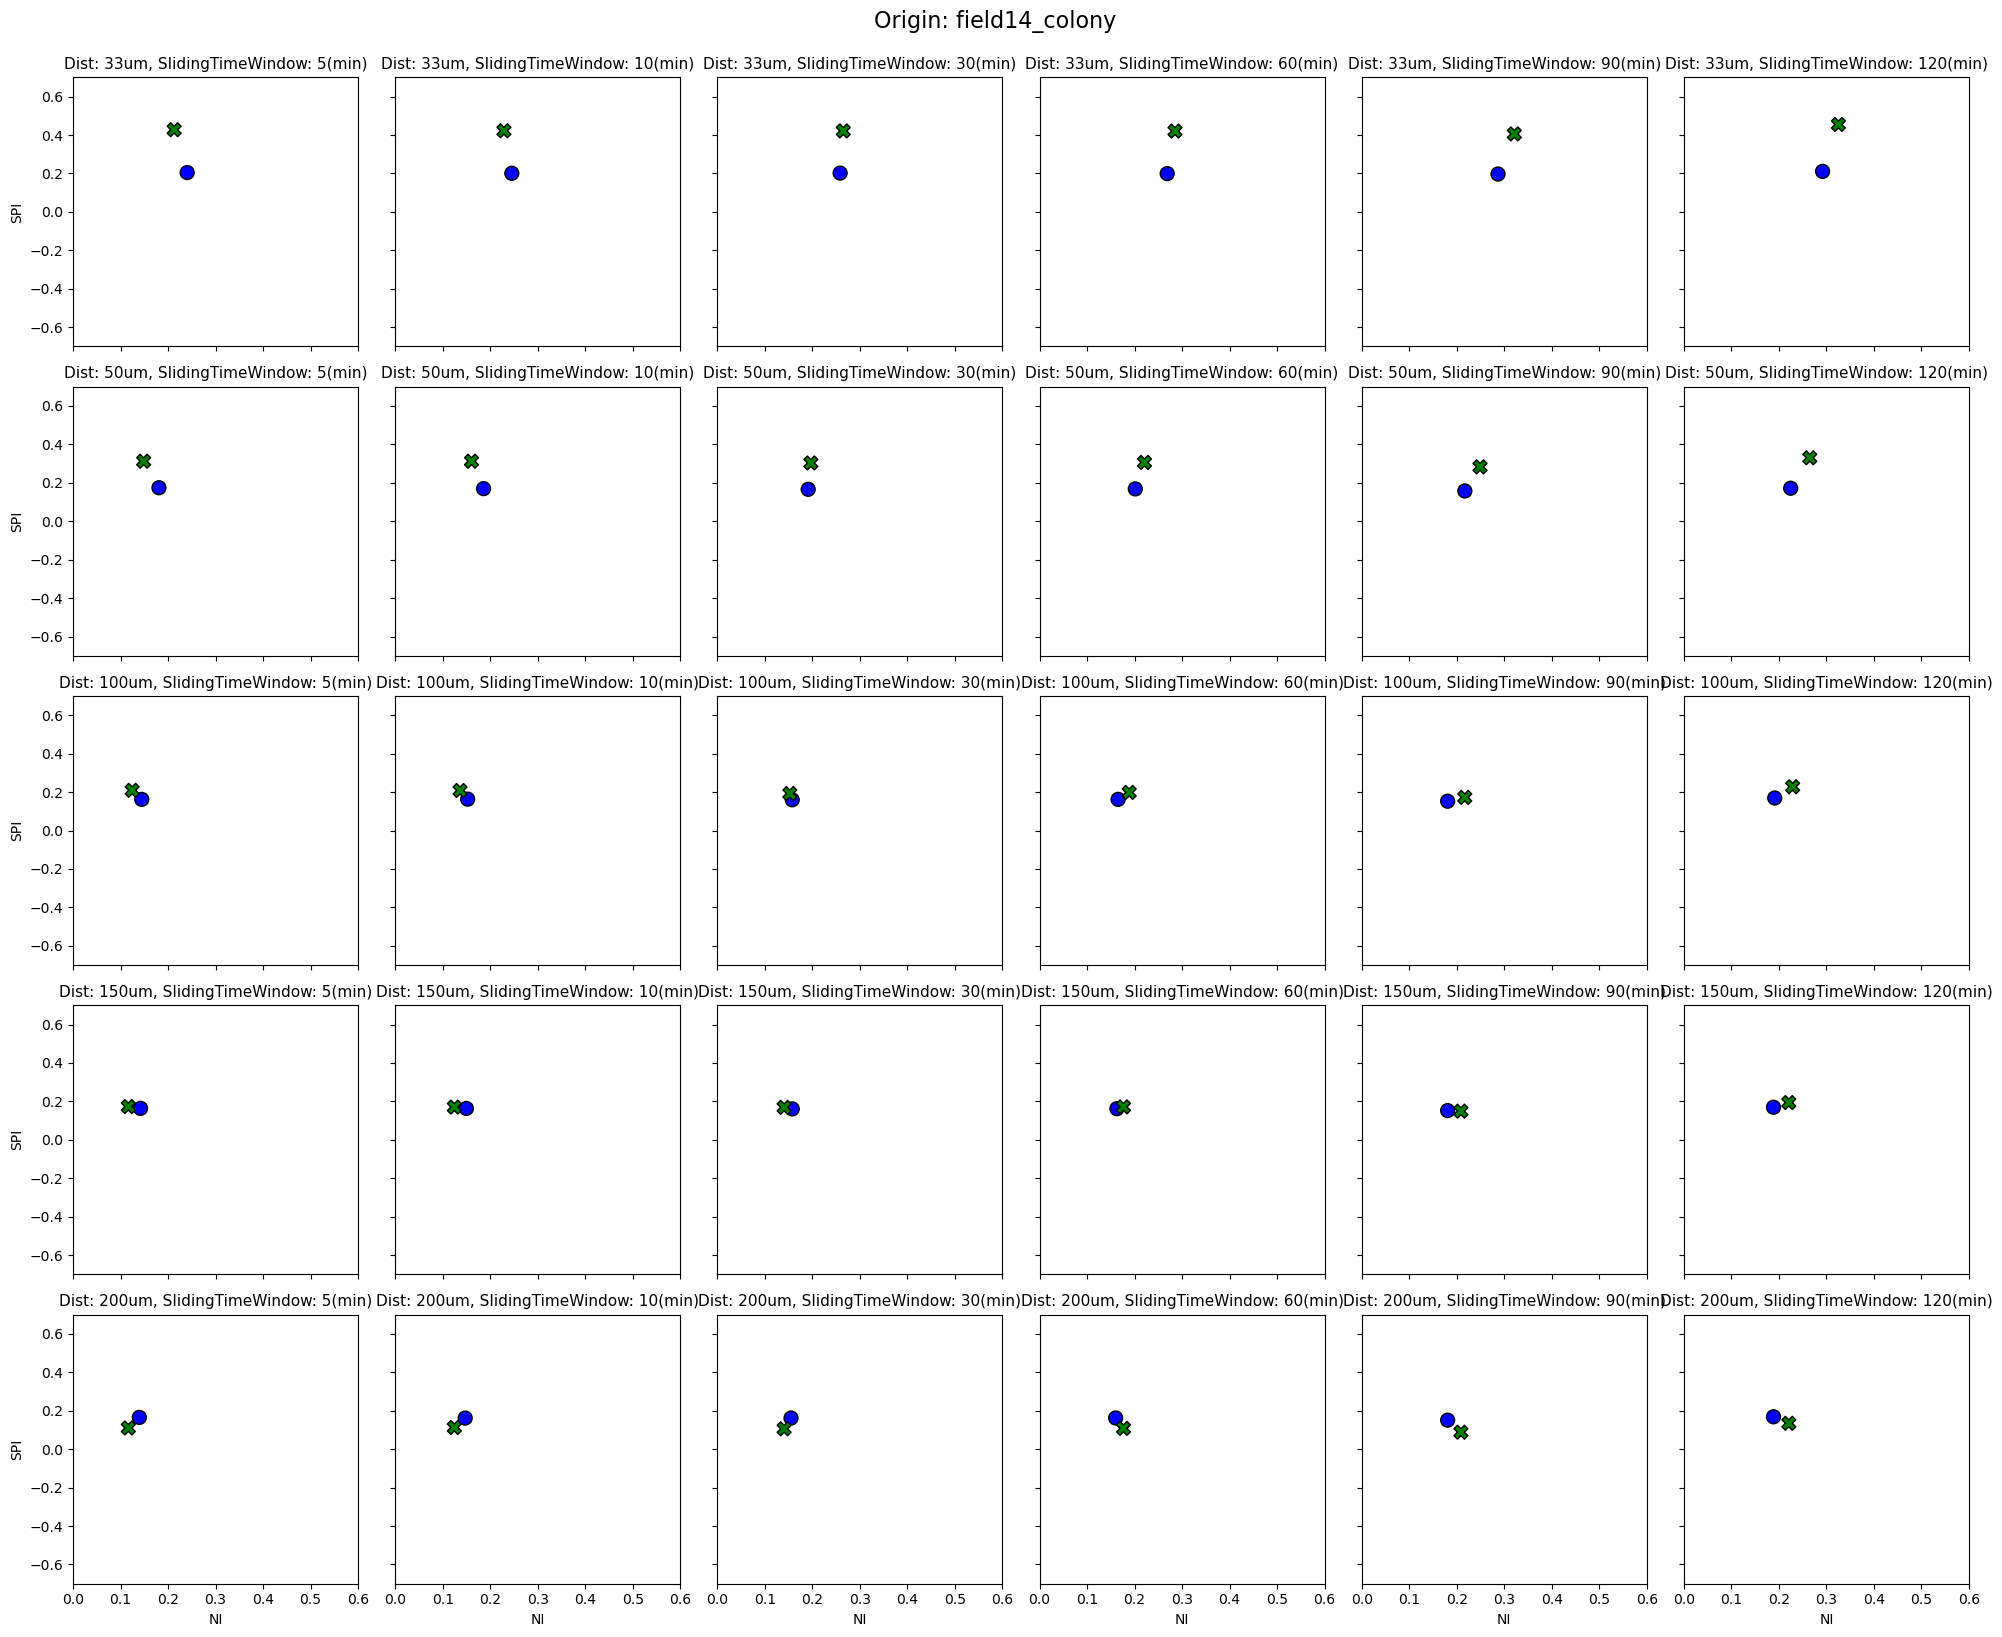

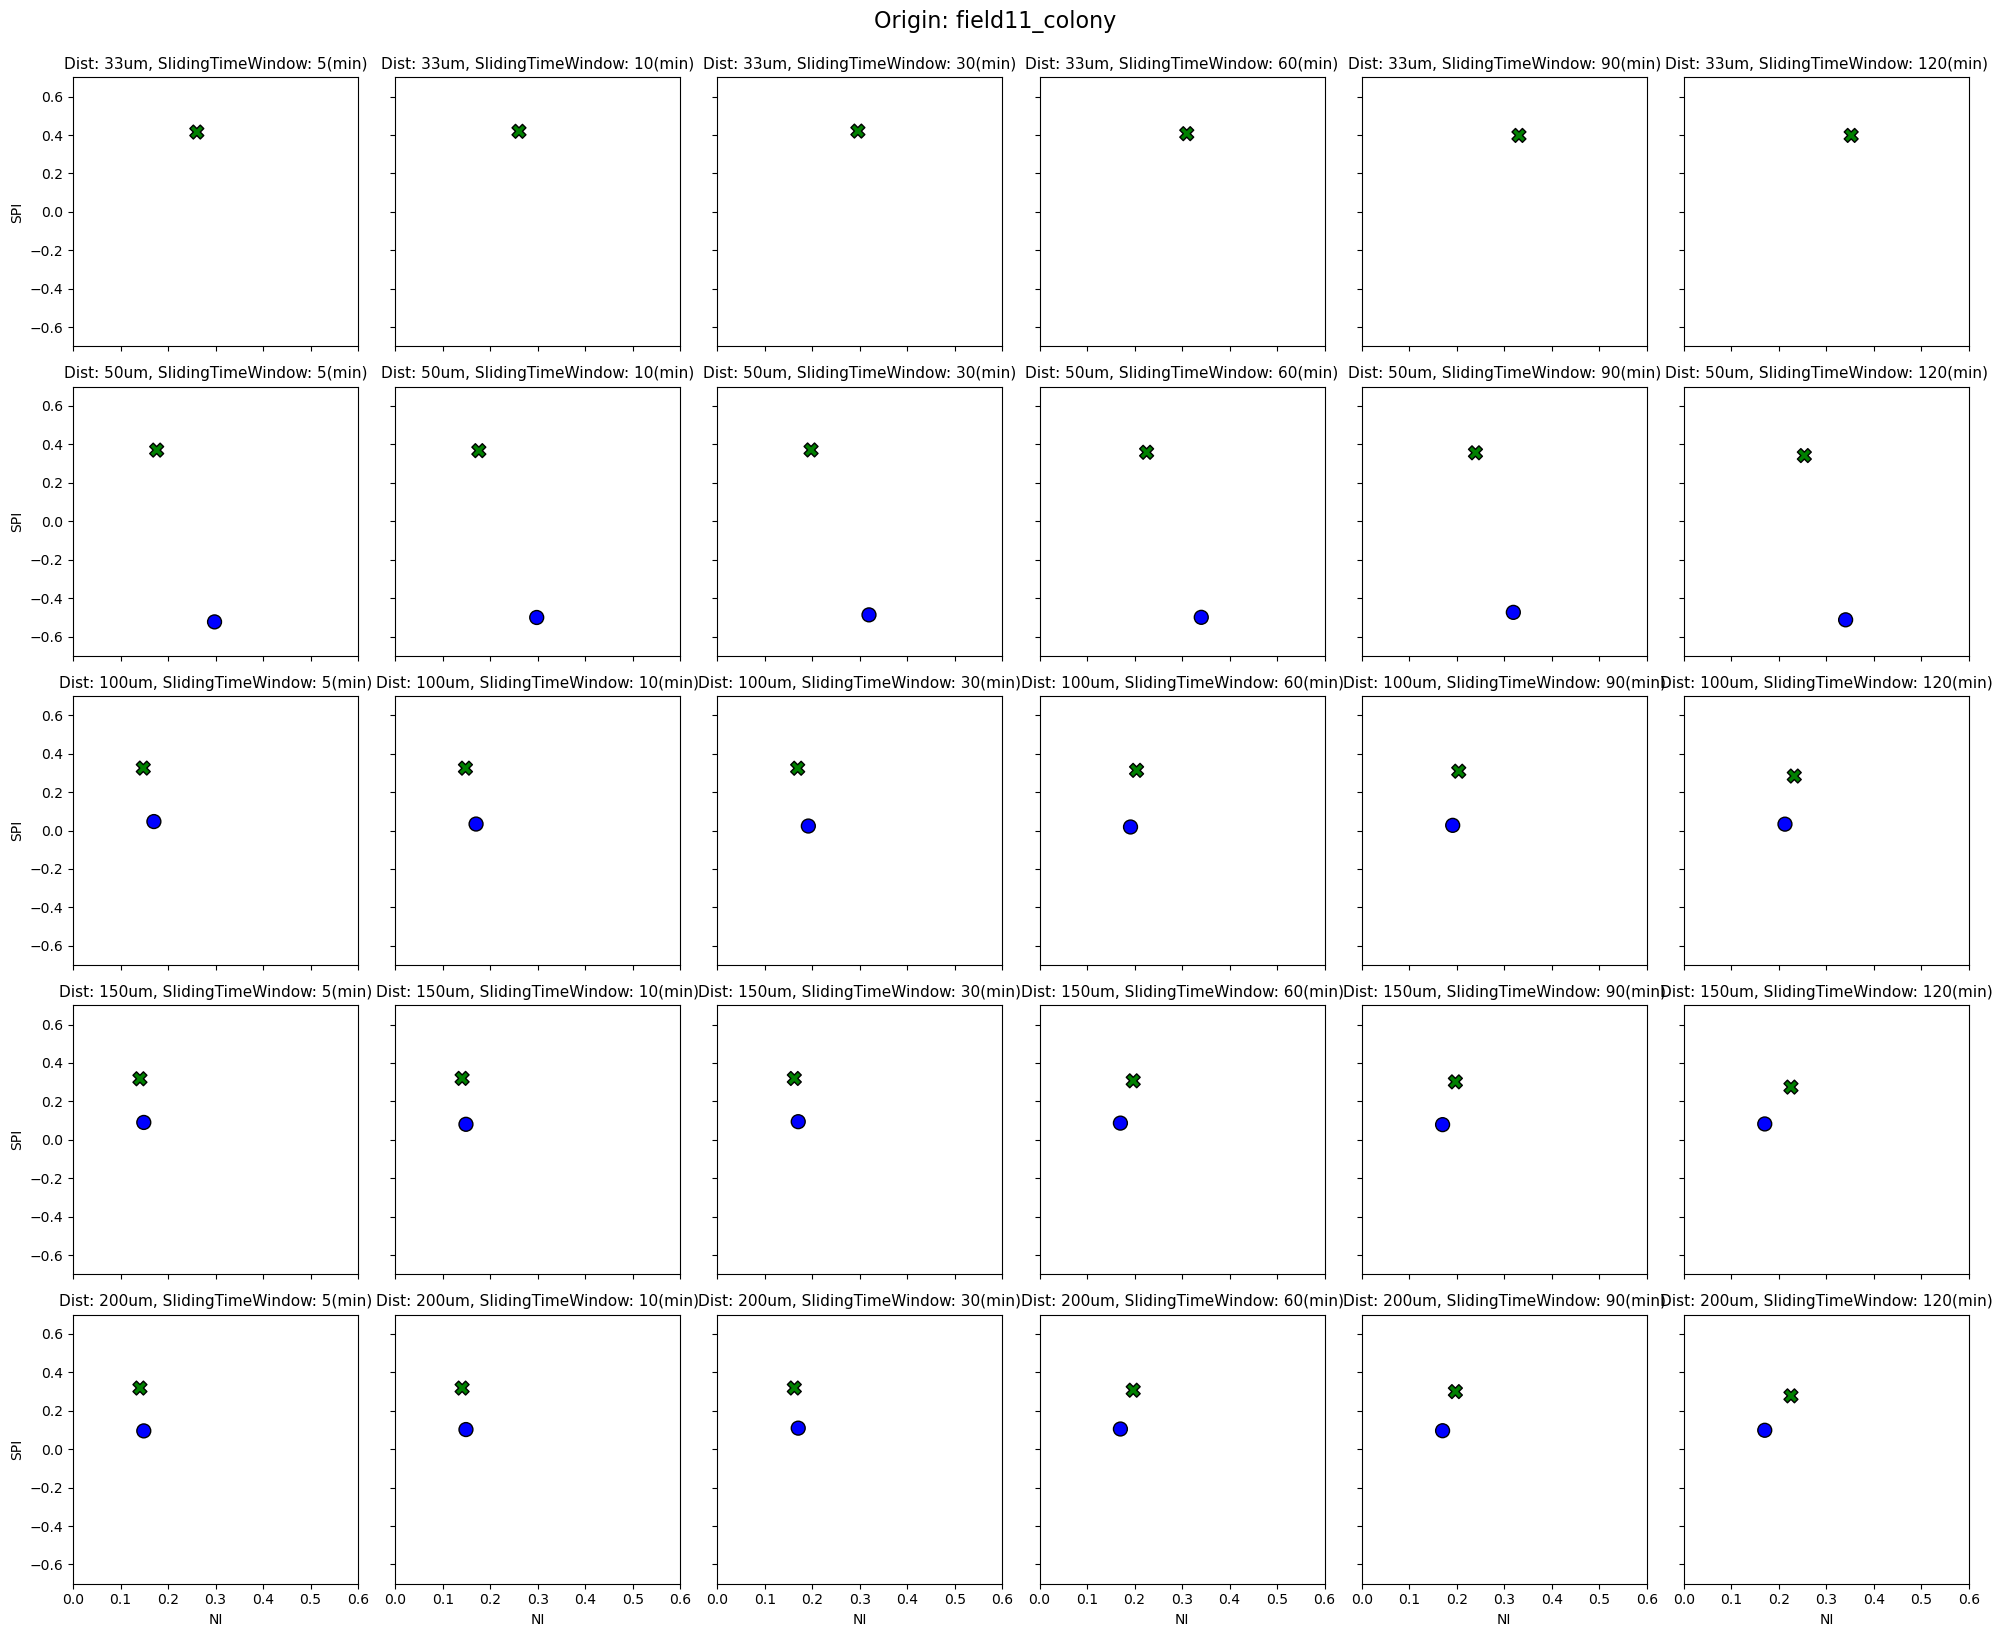

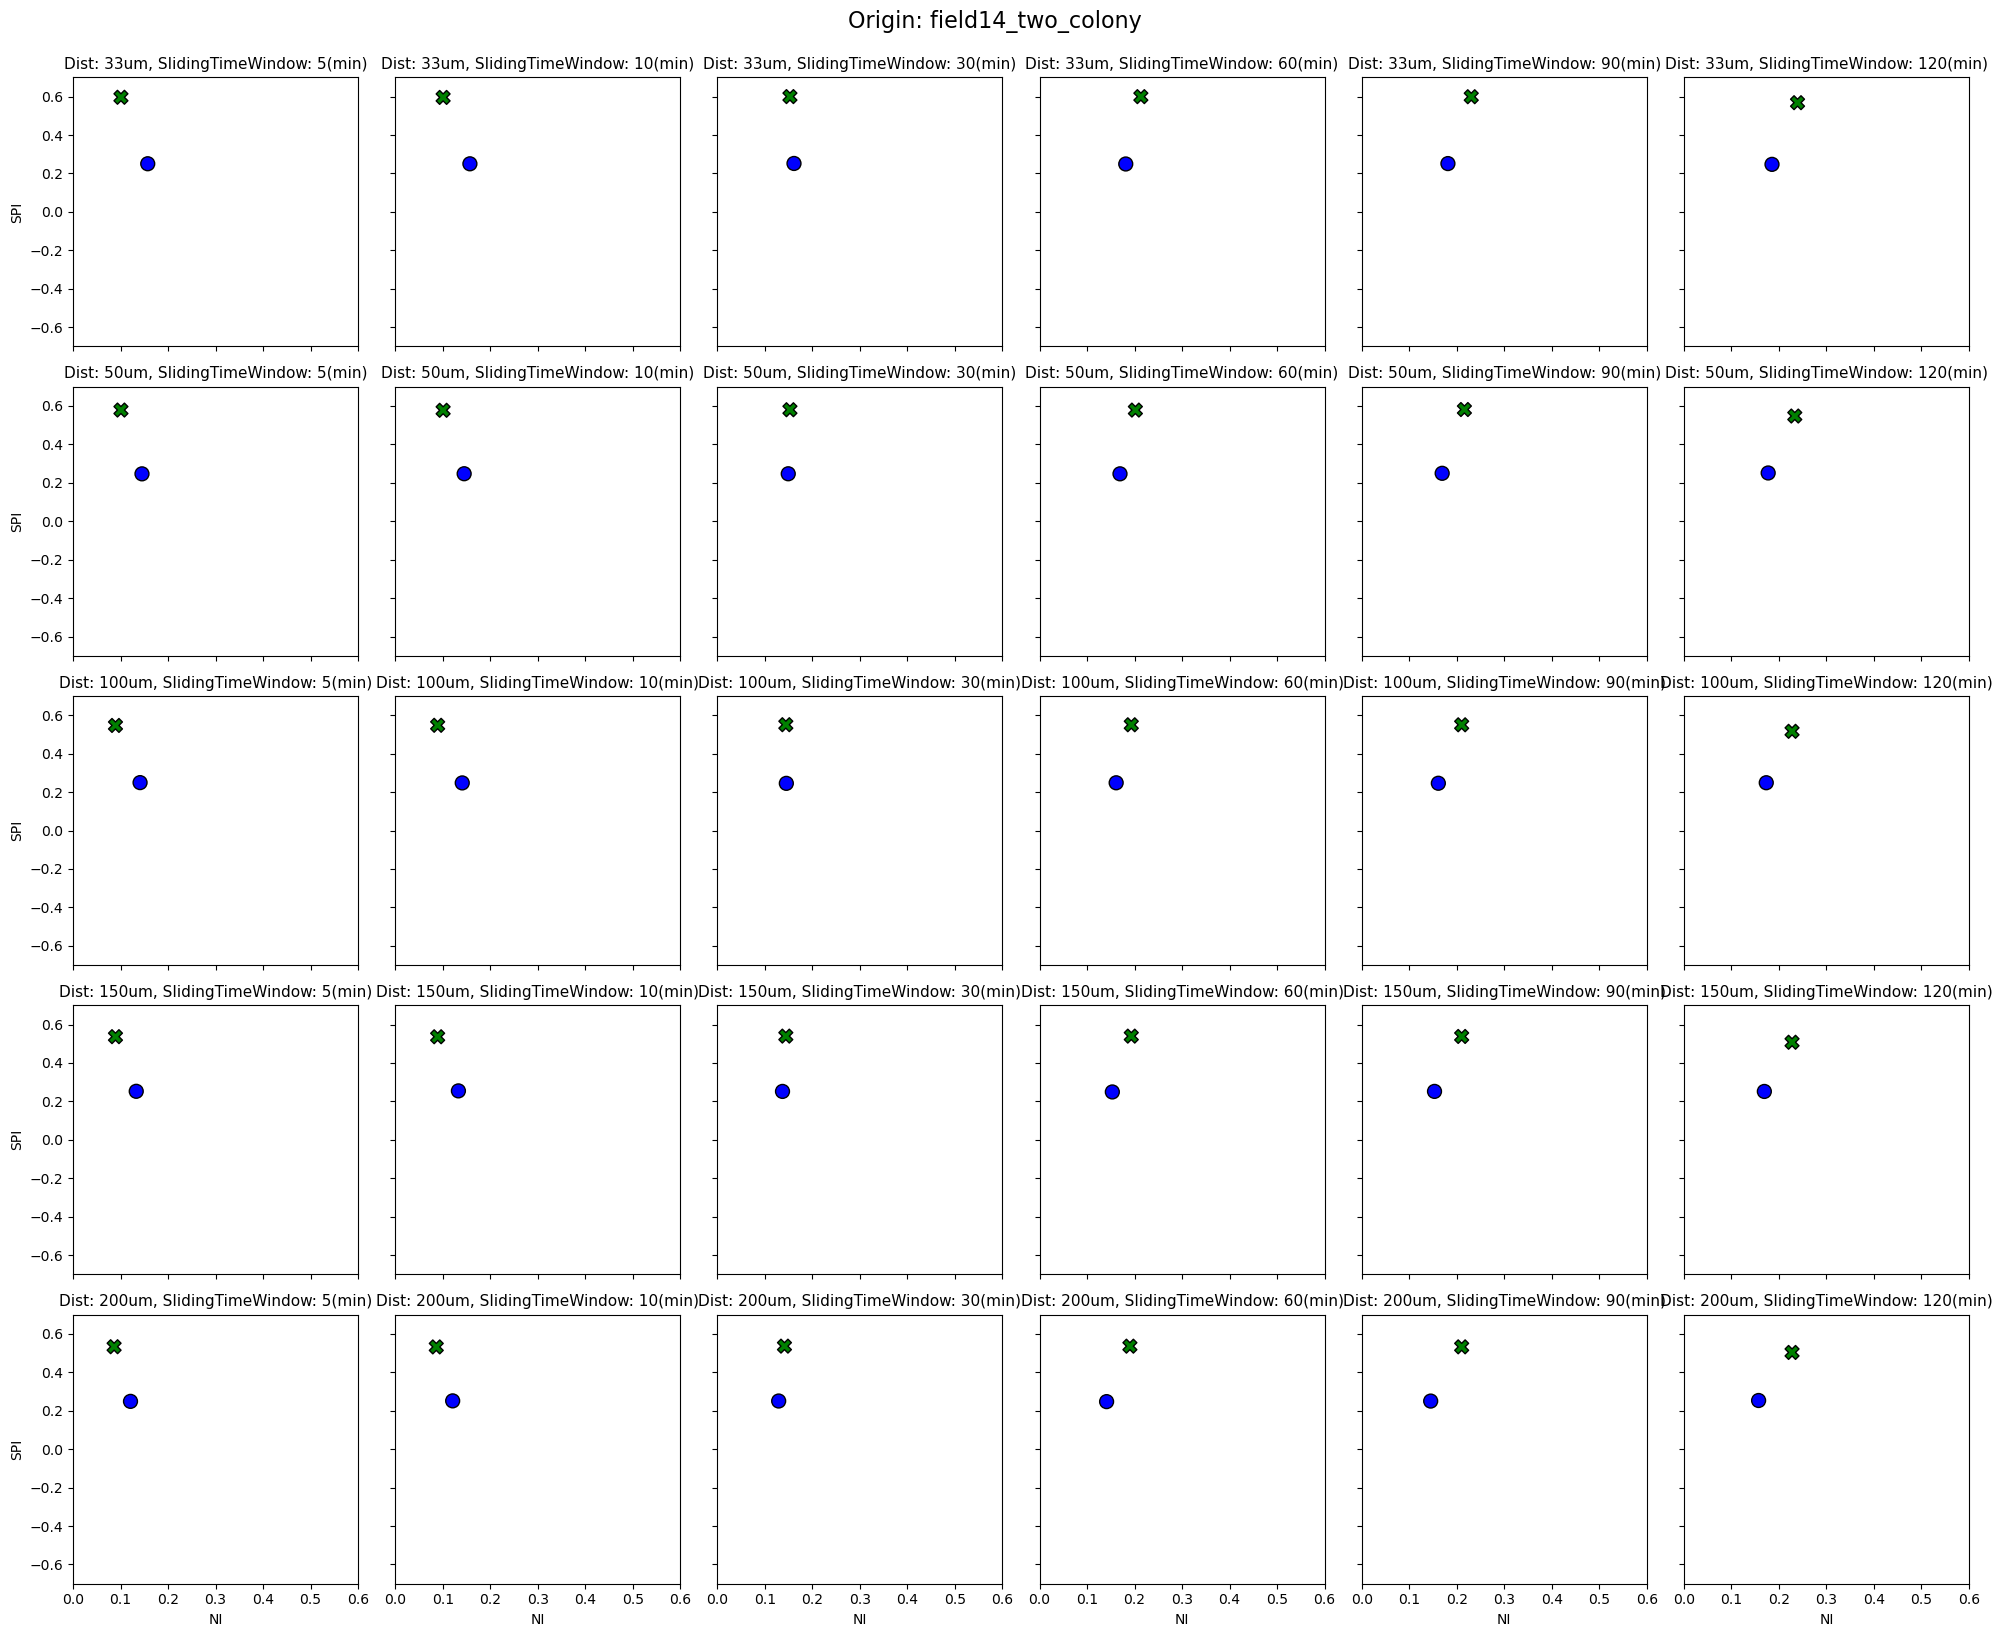

In [14]:
# Define the unique origins
unique_origins = filtered_df['Origin'].unique()

# Iterate over each origin
for origin in unique_origins:
    # Filter the dataframe for the current origin
    origin_subset = filtered_df[filtered_df['Origin'] == origin]
    
    # Define the grid of subplots
    fig, axes = plt.subplots(nrows=5, ncols=6, figsize=(20, 16), sharex=True, sharey=True)
    
    # Define the unique distances and sliding time windows
    distances = origin_subset['neighbors_dist_threshold'].unique()
    sliding_windows = origin_subset['sliding_time_window_size'].unique()
    
    # Sort distances and sliding windows for consistent plotting
    distances = sorted(distances)
    sliding_windows = sorted(sliding_windows)
    
    # Iterate over distances and sliding windows to create subplots
    for i, dist in enumerate(distances):
        for j, window in enumerate(sliding_windows):
            ax = axes[i, j]
            subset = origin_subset[
                (origin_subset['neighbors_dist_threshold'] == dist) &
                (origin_subset['sliding_time_window_size'] == window)
            ]
            
            sns.scatterplot(
                data=subset,
                x="NI",
                y="SPI",
                hue="Treatment",
                style="Mode",
                palette=custom_palette,
                edgecolor="black",
                linewidth=1,
                s=100,
                ax=ax,
                legend=False  # Suppress legend for all subplots
            )
            
            # Add connecting lines between points from the same treatment
            for treatment, group in subset.groupby("Treatment"):
                ax.plot(group["NI"], group["SPI"], linestyle='-', linewidth=1, alpha=0.7, color='b')
            
            # Set subplot title
            # ax.set_title(f"Dist: {dist}, Window: {window}")
            ax.set_xlim(0, 0.6)
            ax.set_ylim(-0.7, 0.7)
            ax.set_title(f"Dist: {dist}um, SlidingTimeWindow: {window}(min)", fontsize = 11)
    
    # Add legend to the last subplot
    handles, labels = axes[-1, -1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='center right', frameon=False)
    
    # Adjust layout and add a title for the origin
    plt.tight_layout()
    fig.suptitle(f"Origin: {origin}", fontsize=16, y=1.02)
    plt.show()


### SPI only: SA

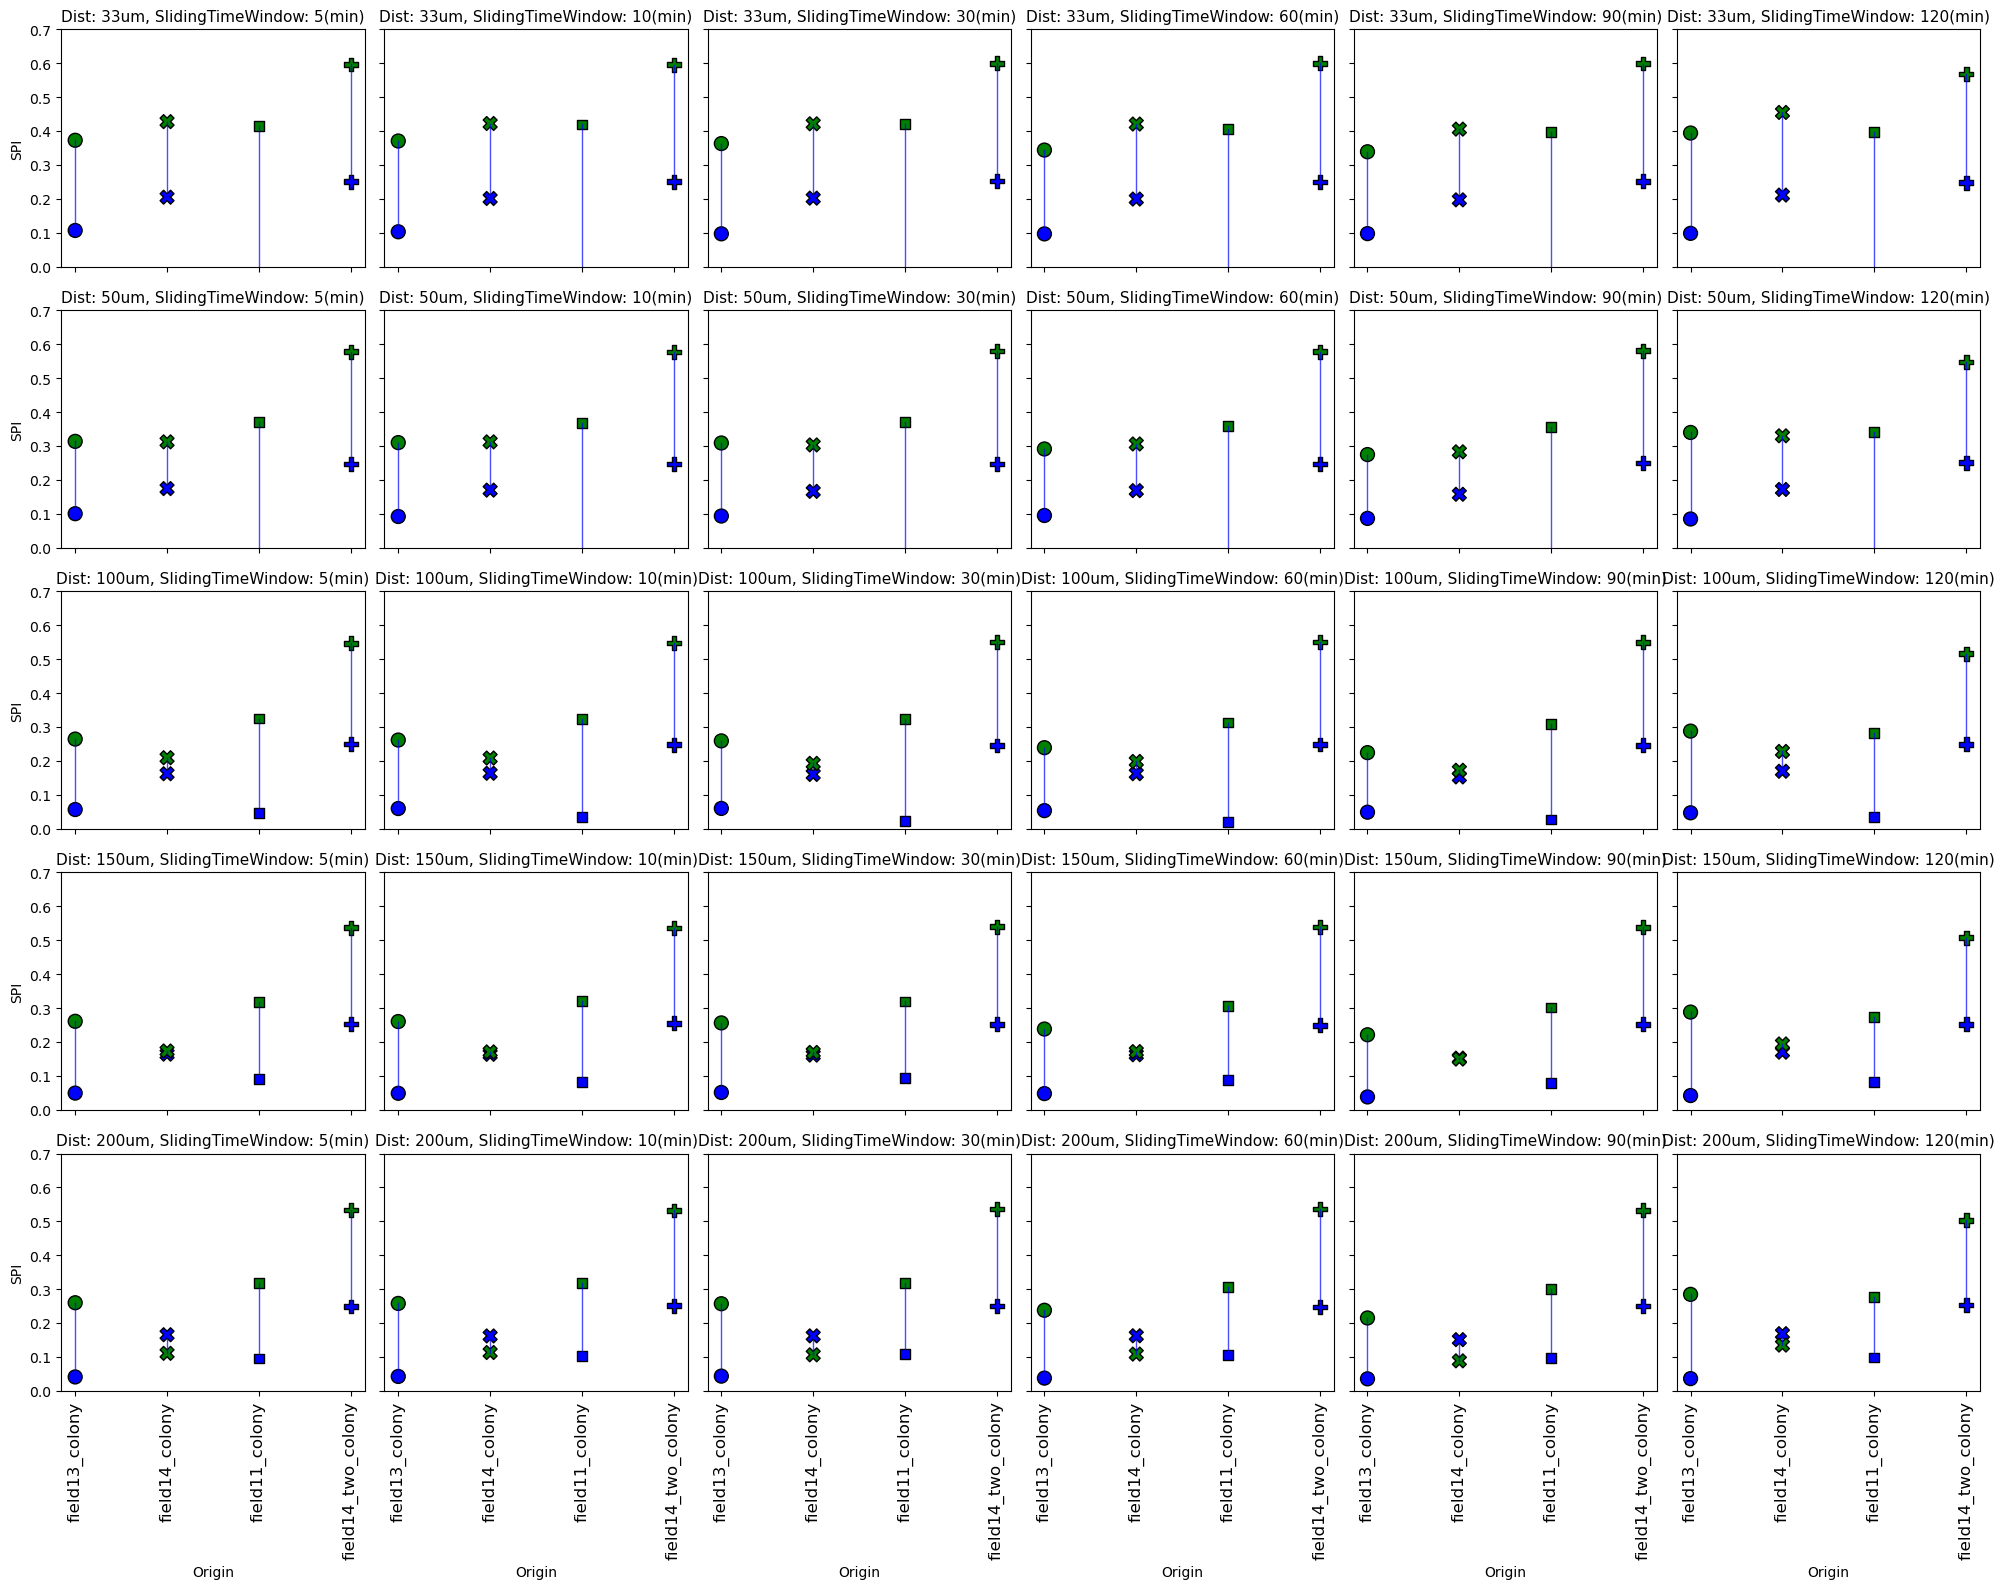

In [13]:
# Define the grid of subplots
# Define the custom palette
custom_palette = {
    'ApoptosisInColonies': 'blue',
    'NecrosisInColonies': 'green'
}
fig, axes = plt.subplots(nrows=5, ncols=6, figsize=(20, 16), sharex=True, sharey=True)

# Define the unique distances and sliding time windows
distances = filtered_df['neighbors_dist_threshold'].unique()
sliding_windows = filtered_df['sliding_time_window_size'].unique()

# Sort distances and sliding windows for consistent plotting
distances = sorted(distances)
sliding_windows = sorted(sliding_windows)

# Iterate over distances and sliding windows to create subplots
for i, dist in enumerate(distances):
    for j, window in enumerate(sliding_windows):
        ax = axes[i, j]
        subset = filtered_df[
            (filtered_df['neighbors_dist_threshold'] == dist) &
            (filtered_df['sliding_time_window_size'] == window)
        ]
        
        sns.scatterplot(
            data=subset,
            x="Origin",
            y="SPI",
            hue="Treatment",
            style="Origin",
            palette=custom_palette,
            edgecolor="black",
            linewidth=1,
            s=100,
            ax=ax,
            legend=False  # Suppress legend for all subplots
        )
        
        # Add connecting lines between points from the same origin
        for origin, group in subset.groupby("Origin"):
            ax.plot(group["Origin"], group["SPI"], linestyle='-', linewidth=1, alpha=0.7, color='b', )
        
        # Set subplot title
        ax.set_title(f"Dist: {dist}um, SlidingTimeWindow: {window}(min)", fontsize = 11)
        ax.set_ylim(0, 0.7)
        ax.tick_params(axis='x', labelsize=12, rotation=90)

# Add legend to the last subplot
handles, labels = axes[-1, -1].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', frameon=False)
# plt.setp(axes, xticks=filtered_df['Origin'].unique(), xticklabels=filtered_df['Origin'].unique(), fontsize=12, rotation=90, ha='right')
# Adjust layout
plt.tight_layout()
plt.show()


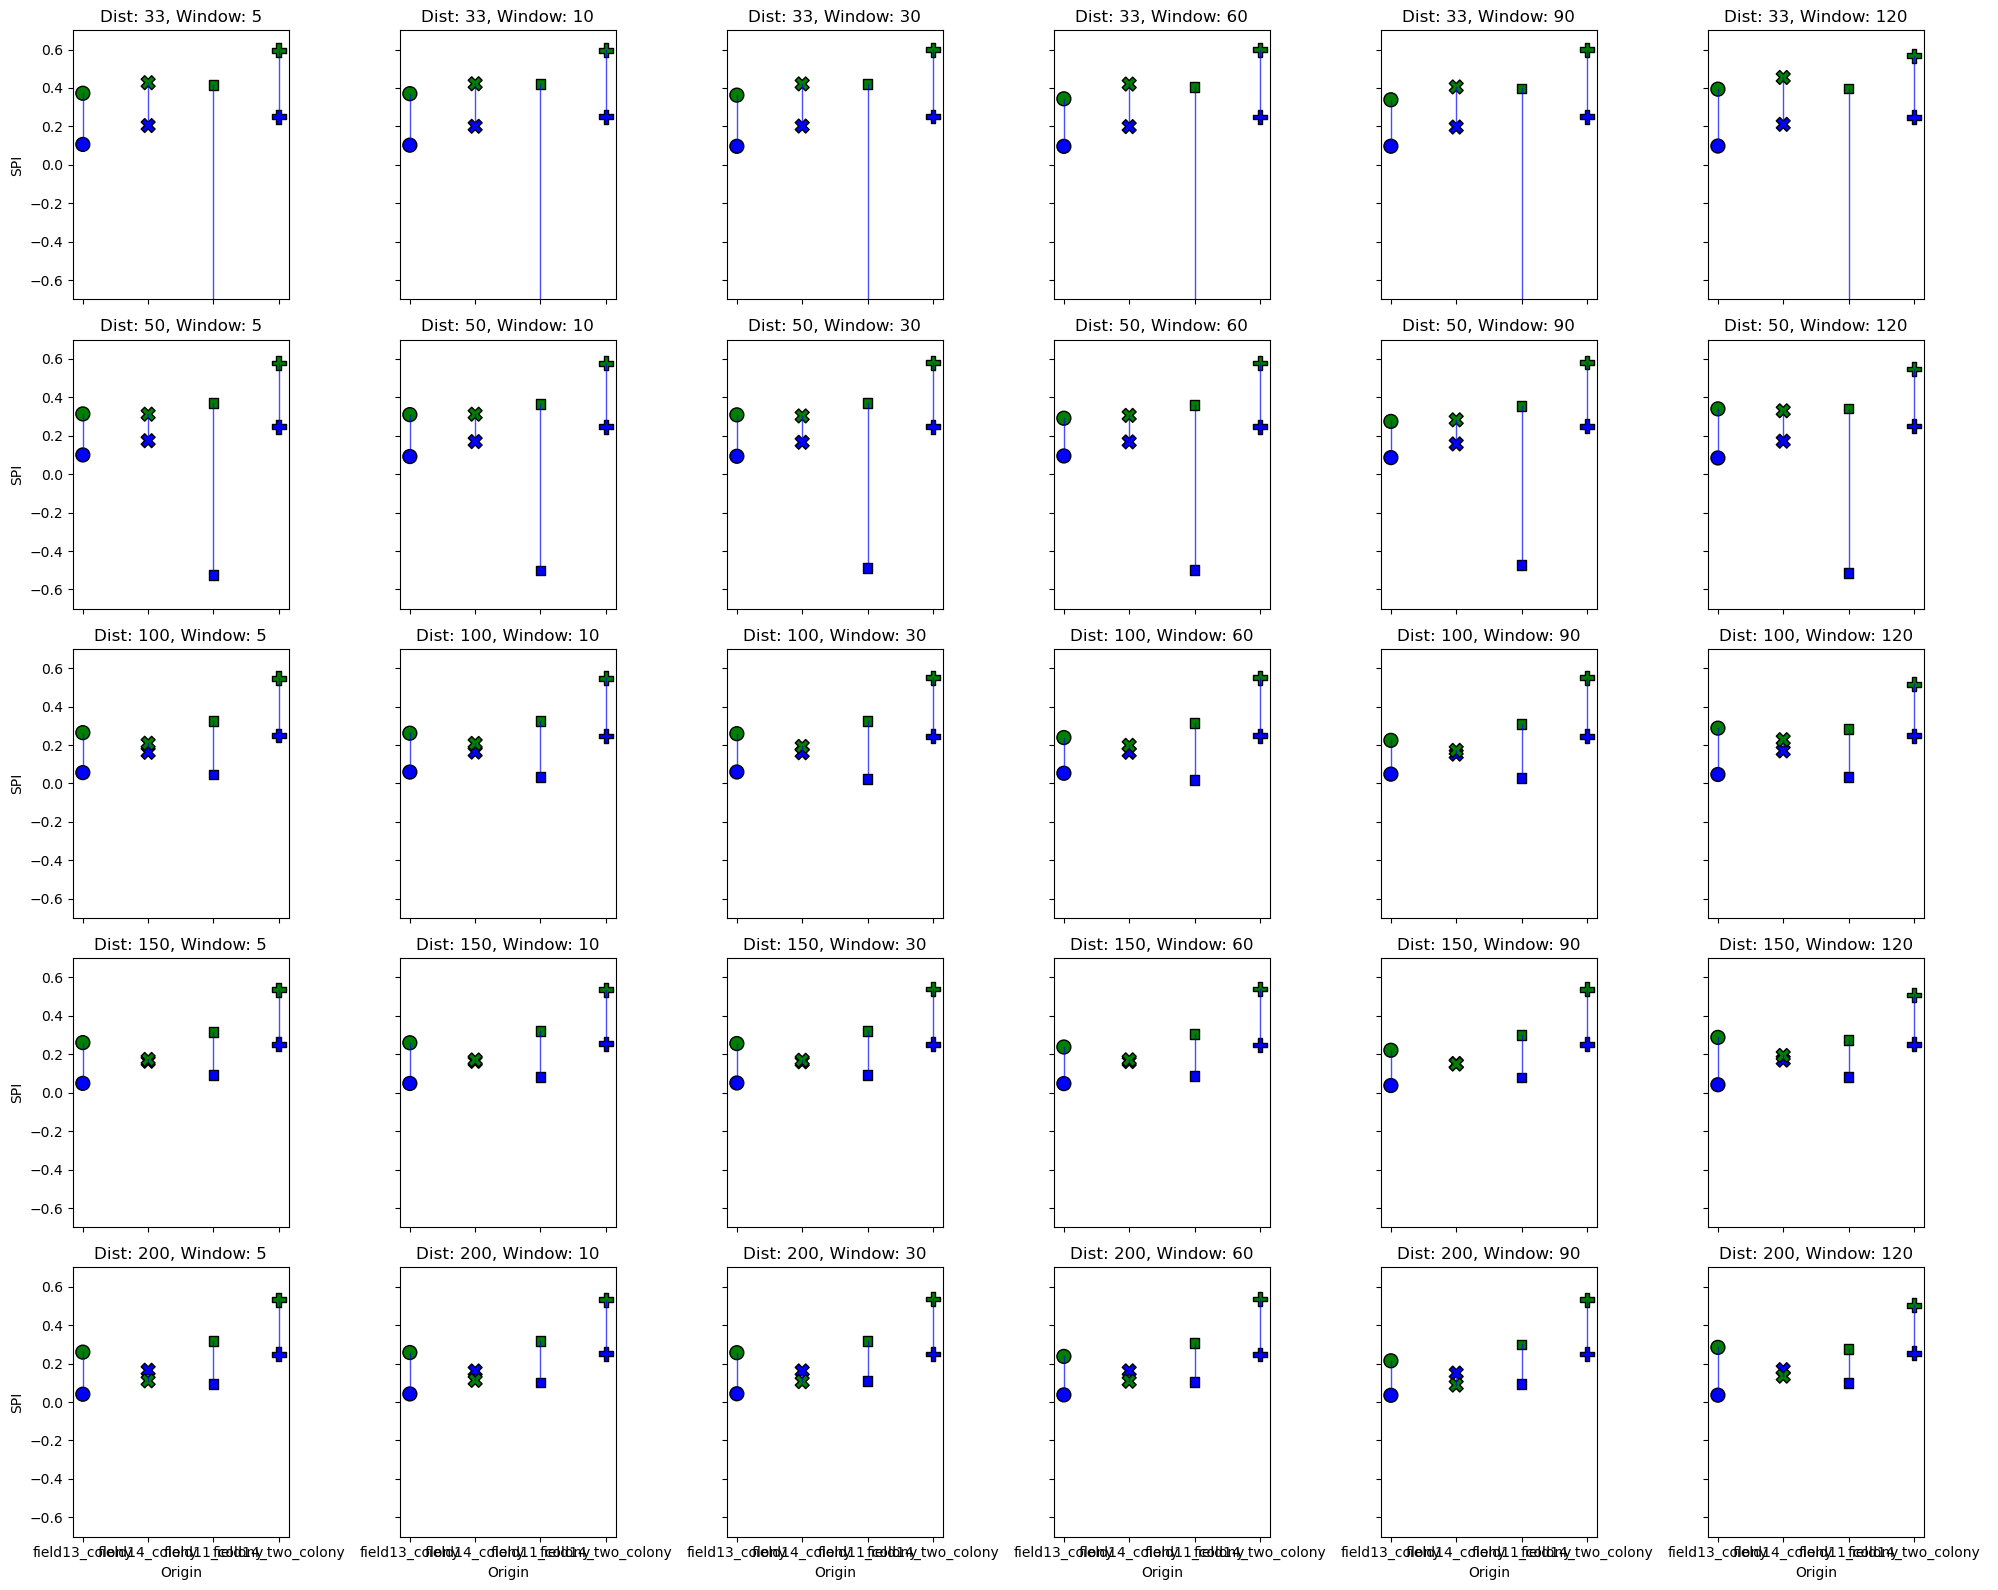

In [3]:
# Define the grid of subplots
# Define the custom palette
custom_palette = {
    'ApoptosisInColonies': 'blue',
    'NecrosisInColonies': 'green'
}
fig, axes = plt.subplots(nrows=5, ncols=6, figsize=(20, 16), sharex=True, sharey=True)

# Define the unique distances and sliding time windows
distances = filtered_df['neighbors_dist_threshold'].unique()
sliding_windows = filtered_df['sliding_time_window_size'].unique()

# Sort distances and sliding windows for consistent plotting
distances = sorted(distances)
sliding_windows = sorted(sliding_windows)

# Iterate over distances and sliding windows to create subplots
for i, dist in enumerate(distances):
    for j, window in enumerate(sliding_windows):
        ax = axes[i, j]
        subset = filtered_df[
            (filtered_df['neighbors_dist_threshold'] == dist) &
            (filtered_df['sliding_time_window_size'] == window)
        ]
        
        sns.scatterplot(
            data=subset,
            x="Origin",
            y="SPI",
            hue="Treatment",
            style="Origin",
            palette=custom_palette,
            edgecolor="black",
            linewidth=1,
            s=100,
            ax=ax,
            legend=False  # Suppress legend for all subplots
        )
        
        # Add connecting lines between points from the same origin
        for origin, group in subset.groupby("Origin"):
            ax.plot(group["Origin"], group["SPI"], linestyle='-', linewidth=1, alpha=0.7, color='b', )
        
        # Set subplot title
        ax.set_title(f"Dist: {dist}, Window: {window}")
        ax.set_ylim(-0.7, 0.7)

# Add legend to the last subplot
handles, labels = axes[-1, -1].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', frameon=False)

# Adjust layout
plt.tight_layout()
plt.show()


### NI only : SA

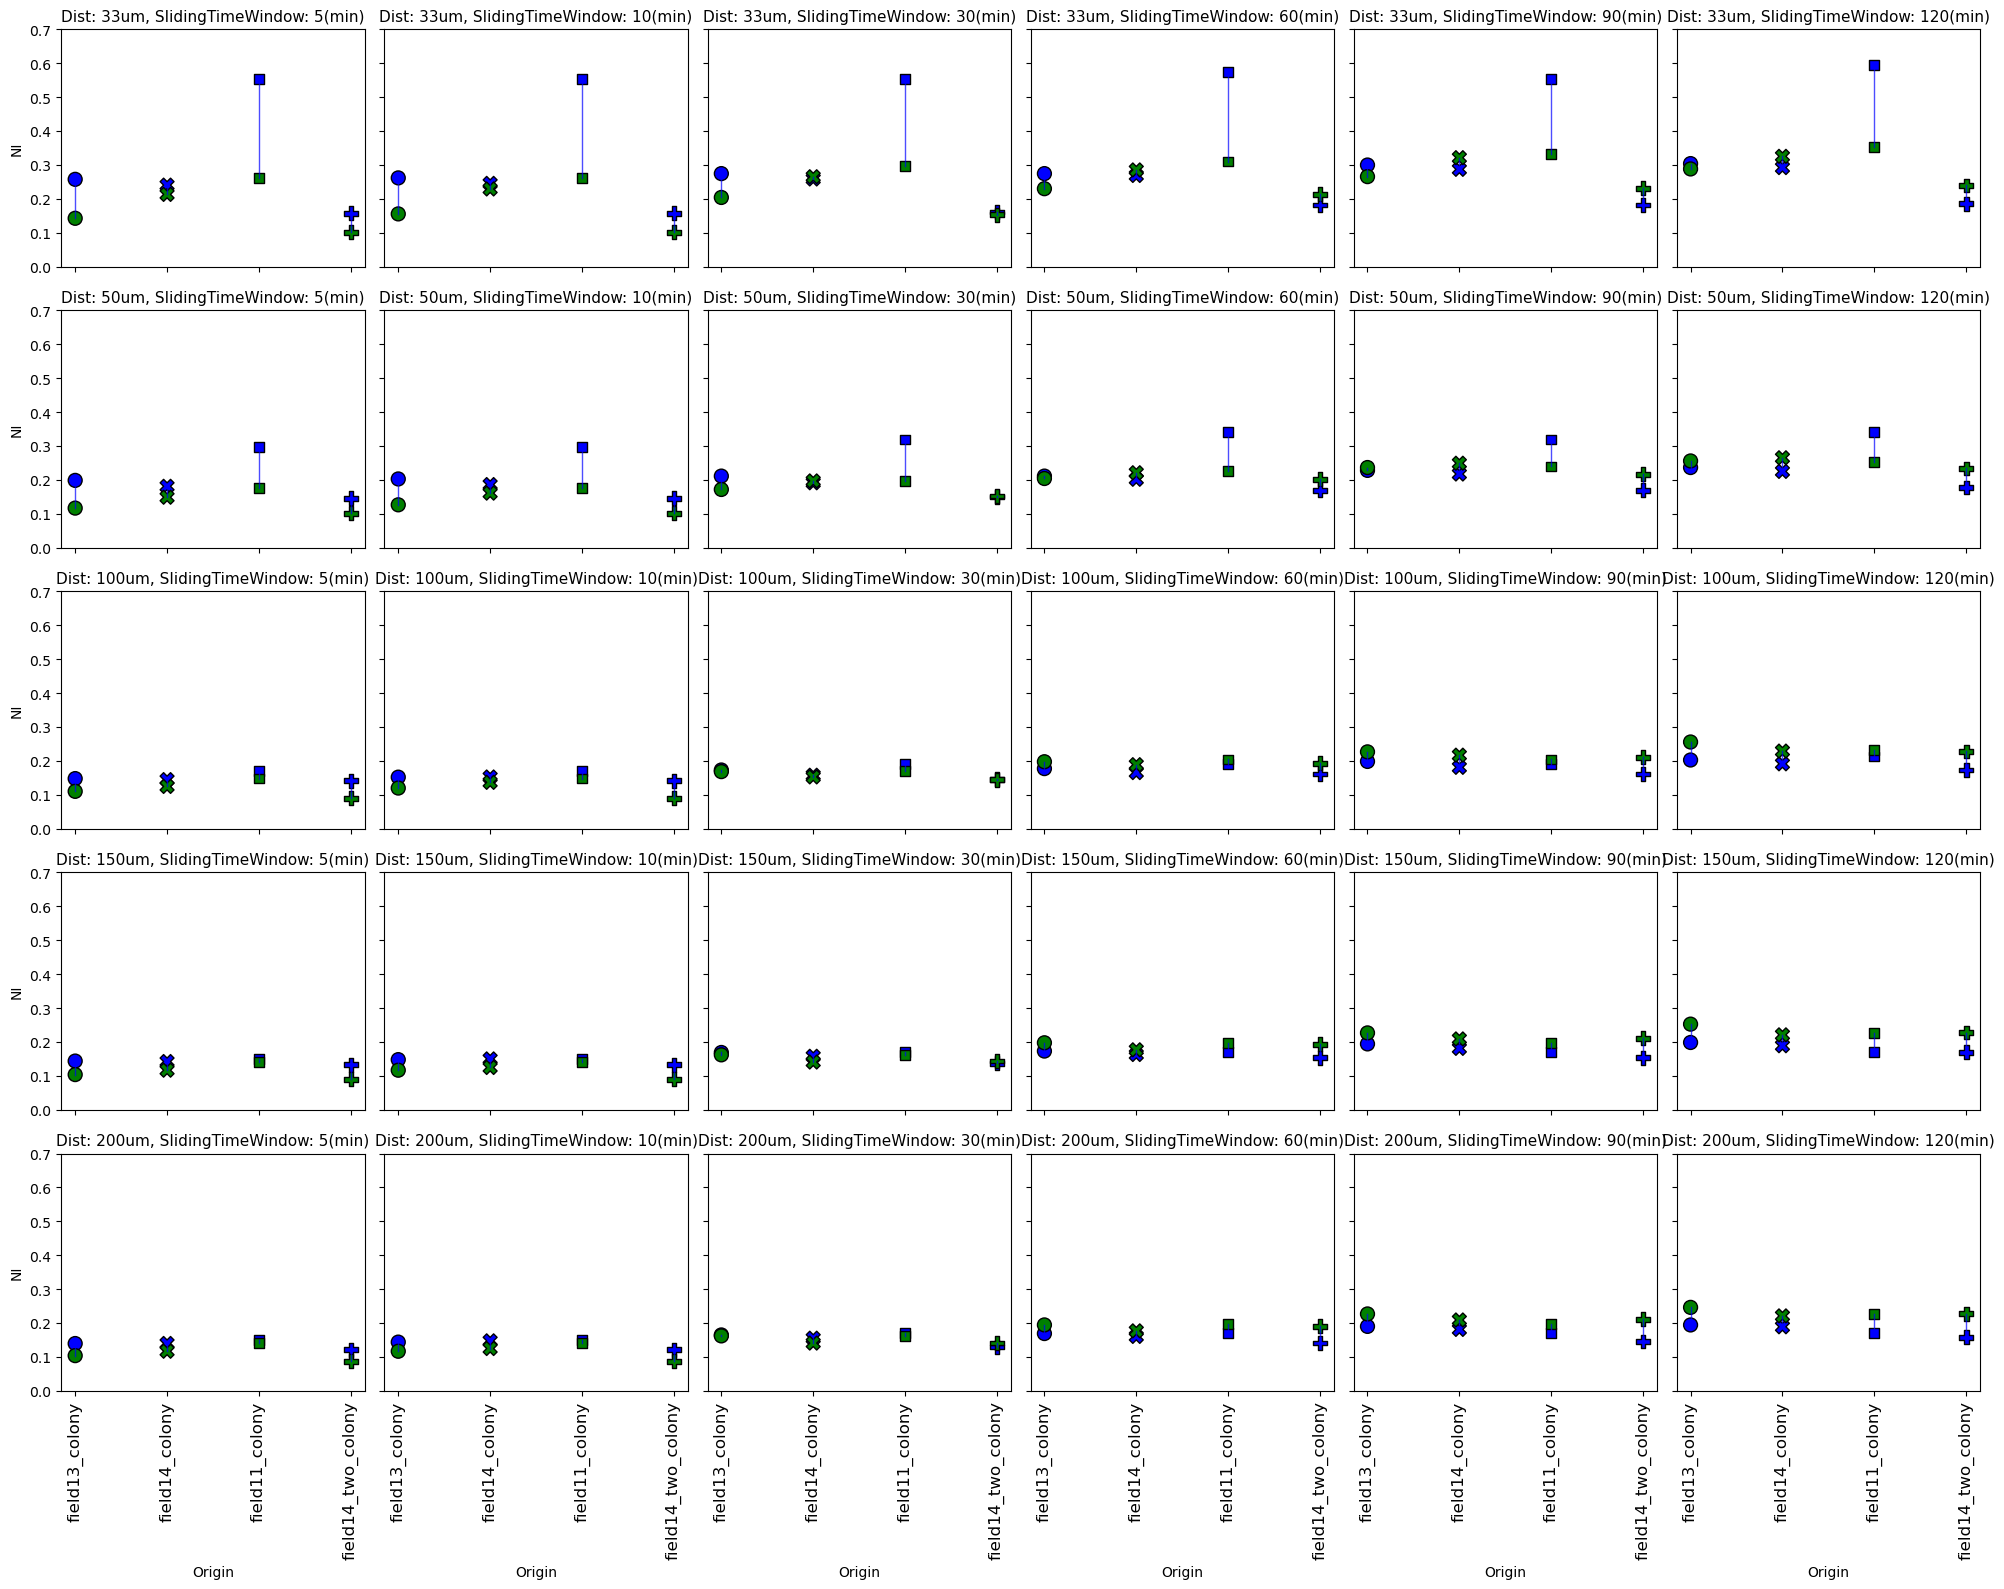

In [16]:
# Define the grid of subplots
# Define the custom palette
custom_palette = {
    'ApoptosisInColonies': 'blue',
    'NecrosisInColonies': 'green'
}
fig, axes = plt.subplots(nrows=5, ncols=6, figsize=(20, 16), sharex=True, sharey=True)

# Define the unique distances and sliding time windows
distances = filtered_df['neighbors_dist_threshold'].unique()
sliding_windows = filtered_df['sliding_time_window_size'].unique()

# Sort distances and sliding windows for consistent plotting
distances = sorted(distances)
sliding_windows = sorted(sliding_windows)

# Iterate over distances and sliding windows to create subplots
for i, dist in enumerate(distances):
    for j, window in enumerate(sliding_windows):
        ax = axes[i, j]
        subset = filtered_df[
            (filtered_df['neighbors_dist_threshold'] == dist) &
            (filtered_df['sliding_time_window_size'] == window)
        ]
        
        sns.scatterplot(
            data=subset,
            x="Origin",
            y="NI",
            hue="Treatment",
            style="Origin",
            palette=custom_palette,
            edgecolor="black",
            linewidth=1,
            s=100,
            ax=ax,
            legend=False  # Suppress legend for all subplots
        )
        
        # Add connecting lines between points from the same origin
        for origin, group in subset.groupby("Origin"):
            ax.plot(group["Origin"], group["NI"], linestyle='-', linewidth=1, alpha=0.7, color='b', )
        
        # Set subplot title
        ax.set_title(f"Dist: {dist}um, SlidingTimeWindow: {window}(min)", fontsize = 11)
        ax.set_ylim(0, 0.7)
        ax.tick_params(axis='x', labelsize=12, rotation=90)

# Add legend to the last subplot
handles, labels = axes[-1, -1].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', frameon=False)
# plt.setp(axes, xticks=filtered_df['Origin'].unique(), xticklabels=filtered_df['Origin'].unique(), fontsize=12, rotation=90, ha='right')
# Adjust layout
plt.tight_layout()
plt.show()


### single figure

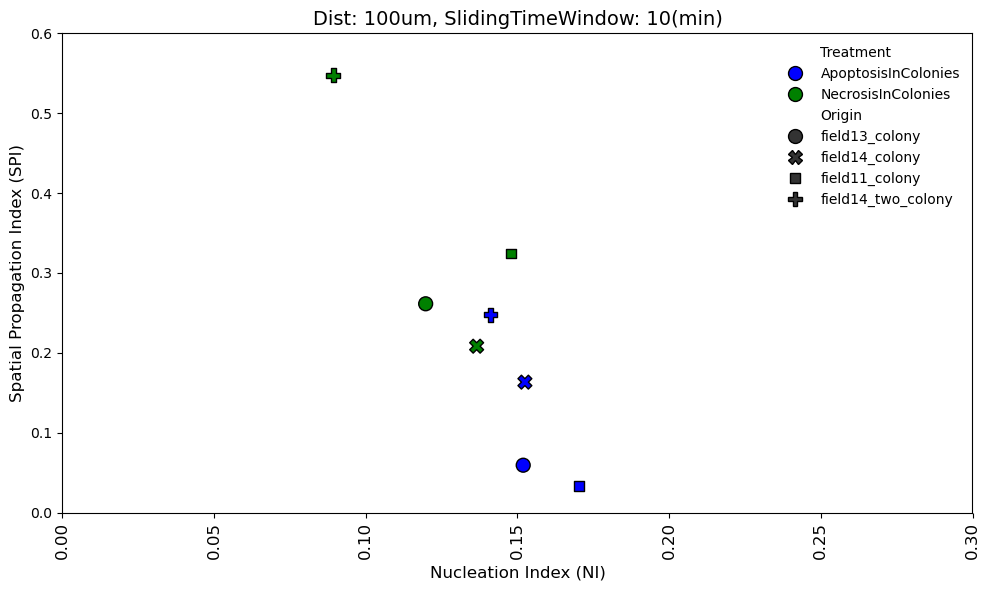

In [ ]:
# Define the grid of subplots
# Define the custom palette
custom_palette = {
    'ApoptosisInColonies': 'blue',
    'NecrosisInColonies': 'green'
}

# Filter the data for distance of 100 and sliding time window of 10
filtered_subset = filtered_df[
    (filtered_df['neighbors_dist_threshold'] == 100) &
    (filtered_df['sliding_time_window_size'] == 10)
]

# Create a new figure for the specific plot
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=filtered_subset,
    x="NI",
    y="SPI",
    hue="Treatment",
    style="Origin",
    palette=custom_palette,
    edgecolor="black",
    linewidth=1,
    s=100,
    ax=ax
)

# Add connecting lines between points from the same origin


# Customize the plot
ax.set_title("Dist: 100um, SlidingTimeWindow: 10(min)", fontsize=14)
ax.set_xlabel("Nucleation Index (NI)", fontsize=12)
ax.set_ylabel("Spatial Propagation Index (SPI)", fontsize=12)
ax.set_ylim(0, 0.6)
ax.set_xlim(0, 0.3)
ax.tick_params(axis='x', labelsize=12, rotation=90)

# Add legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper right', frameon=False)

plt.tight_layout()
plt.savefig("/home/esraan/CellDeathSpreading/results/SPIvsNI100um10min.svg", format="svg")
plt.show()

### Paper figure 

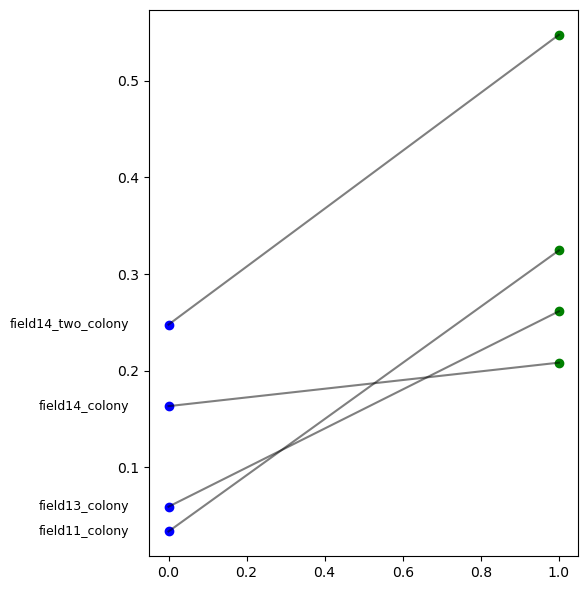

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Example data
custom_palette = {
    'ApoptosisInColonies': 'blue',
    'NecrosisInColonies': 'green'
}
filtered_subset = filtered_df[
    (filtered_df['neighbors_dist_threshold'] == 100) &
    (filtered_df['sliding_time_window_size'] == 10)
]
# X positions: 0 for Group A, 1 for Group B
x_a = np.zeros(len(origins))
x_b = np.ones(len(origins))
# Replace treatment with origin and group values
origins = filtered_subset['Origin'].unique()
group_a_values = []
group_b_values = []
origins_list = []

for origin in origins:
    subset = filtered_subset[filtered_subset['Origin'] == origin]
    group_a = subset[subset['Treatment'] == 'ApoptosisInColonies']['SPI'].mean()
    group_b = subset[subset['Treatment'] == 'NecrosisInColonies']['SPI'].mean()
    if not np.isnan(group_a) and not np.isnan(group_b):
        group_a_values.append(group_a)
        group_b_values.append(group_b)
        origins_list.append(origin)

# Plot
plt.figure(figsize=(6, 6))

for i in range(len(origins_list)):
    # Line connecting values
    plt.plot([x_a[i], x_b[i]], [group_a_values[i], group_b_values[i]], 'k-', alpha=0.5)
    # Group A point
    plt.scatter(x_a[i], group_a_values[i], color=custom_palette['ApoptosisInColonies'], label='ApoptosisInColonies' if i == 0 else "")
    # Group B point
    plt.scatter(x_b[i], group_b_values[i], color=custom_palette['NecrosisInColonies'], label='NecrosisInColonies' if i == 0 else "")
    # Origin label on left
    plt.text(-0.1, group_a_values[i], origins_list[i], va='center', ha='right', fontsize=9)
# plt.figure(figsize=(6, 6))

# for i in range(len(treatments)):
#     # Line connecting values
#     plt.plot([x_a[i], x_b[i]], [group_a_values[i], group_b_values[i]], 'k-', alpha=0.5)
#     # Group A point
#     plt.scatter(x_a[i], group_a_values[i], color='blue', label='Group A' if i == 0 else "")
#     # Group B point
#     plt.scatter(x_b[i], group_b_values[i], color='red', label='Group B' if i == 0 else "")
#     # Treatment label on left
#     plt.text(-0.1, group_a_values[i], treatments[i], va='center', ha='right', fontsize=9)

# # Formatting
# plt.xticks([0, 1], ['Group A', 'Group B'])
# plt.ylabel("Value")
# plt.title("Paired Treatment Values Across Groups")
# plt.legend()
# plt.grid(True, axis='y', linestyle='--', alpha=0.3)
# plt.xlim(-0.5, 1.5)
plt.tight_layout()
plt.show()


## SPI only

### single marker

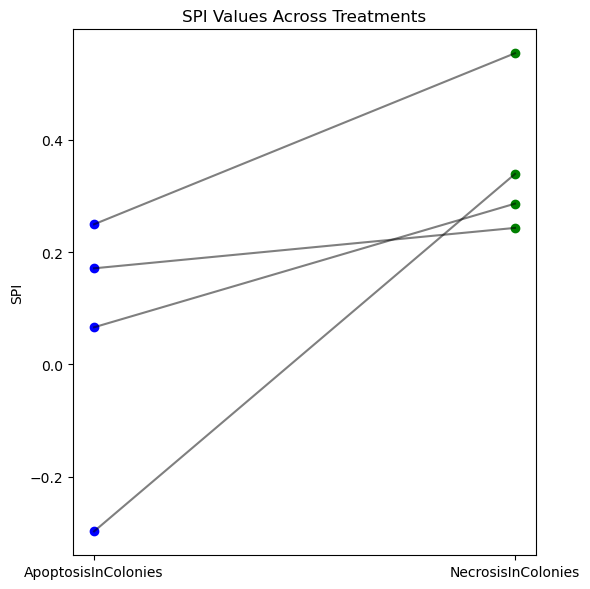

In [35]:
import matplotlib.pyplot as plt
import numpy as np

custom_palette = {
    'ApoptosisInColonies': 'blue',
    'NecrosisInColonies': 'green'
}

# Replace treatment with origin and group values
origins = filtered_df['Origin'].unique()
group_a_values = []
group_b_values = []
treatment_labels = []

for origin in origins:
    subset = filtered_df[filtered_df['Origin'] == origin]
    group_a = subset[subset['Treatment'] == 'ApoptosisInColonies']['SPI'].mean()
    group_b = subset[subset['Treatment'] == 'NecrosisInColonies']['SPI'].mean()
    if not np.isnan(group_a) and not np.isnan(group_b):
        group_a_values.append(group_a)
        group_b_values.append(group_b)
        treatment_labels.append(origin)  # Use treatment labels instead of origin

# Plot
plt.figure(figsize=(6, 6))

for i in range(len(treatment_labels)):
    # Line connecting values
    plt.plot([x_a[i], x_b[i]], [group_a_values[i], group_b_values[i]], 'k-', alpha=0.5)
    # Group A point
    plt.scatter(x_a[i], group_a_values[i], color=custom_palette['ApoptosisInColonies'], label='ApoptosisInColonies' if i == 0 else "")
    # Group B point
    plt.scatter(x_b[i], group_b_values[i], color=custom_palette['NecrosisInColonies'], label='NecrosisInColonies' if i == 0 else "")

# Formatting
plt.xticks([0, 1], ['ApoptosisInColonies', 'NecrosisInColonies'])
plt.ylabel("SPI")
plt.title("SPI Values Across Treatments")
plt.legend().remove()
plt.grid(False)#, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


### Multi-marker

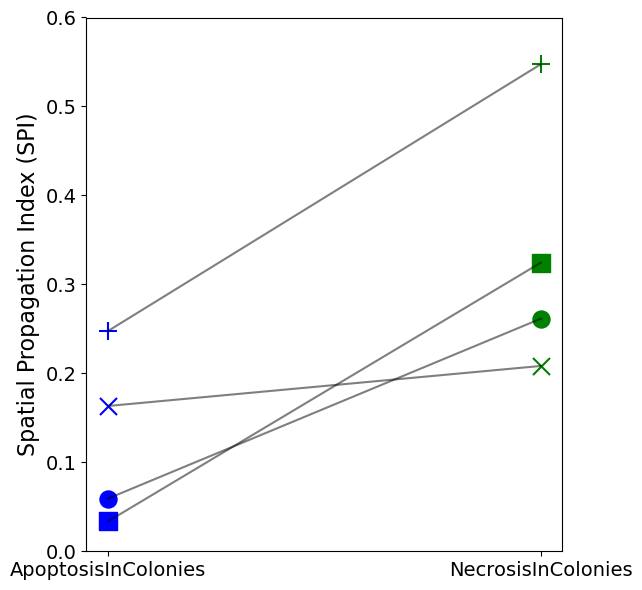

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Example data
custom_palette = {
    'ApoptosisInColonies': 'blue',
    'NecrosisInColonies': 'green'
}

# Replace treatment with origin and group values
# Filter the data for distance of 100 and sliding time window of 10
filtered_subset = filtered_df[
    (filtered_df['neighbors_dist_threshold'] == 100) &
    (filtered_df['sliding_time_window_size'] == 10)
]
origins = filtered_subset['Origin'].unique()
group_a_values = []
group_b_values = []
treatment_labels = []
markers = ['o', 'x', 's', '+']
origin_marker_dict = {origin: markers[i % len(markers)] for i, origin in enumerate(origins)}
# X positions: 0 for Group A, 1 for Group B
x_a = np.zeros(len(origins))
x_b = np.ones(len(origins))
# Assign markers based on origin
origin_markers = [origin_marker_dict[origin] for origin in origins]
for origin in origins:
    subset = filtered_subset[filtered_subset['Origin'] == origin]
    group_a = subset[subset['Treatment'] == 'ApoptosisInColonies']['SPI'].mean()
    group_b = subset[subset['Treatment'] == 'NecrosisInColonies']['SPI'].mean()
    if not np.isnan(group_a) and not np.isnan(group_b):
        group_a_values.append(group_a)
        group_b_values.append(group_b)
        treatment_labels.append(origin)  # Use treatment labels instead of origin

# Plot
plt.figure(figsize=(6.5, 6))

for i in range(len(treatment_labels)):
    # Line connecting values
    plt.plot([x_a[i], x_b[i]], [group_a_values[i], group_b_values[i]], 'k-', alpha=0.5)
    # Group A point
    plt.scatter(x_a[i], group_a_values[i], color=custom_palette['ApoptosisInColonies'], marker=origin_markers[i], label='ApoptosisInColonies' if i == 0 else "", s=150)
    # Group B point
    plt.scatter(x_b[i], group_b_values[i], color=custom_palette['NecrosisInColonies'], marker=origin_markers[i], label='NecrosisInColonies' if i == 0 else "", s=150)

custom_legend = [Line2D([0], [0], marker=marker, color='k', markerfacecolor='k', markersize=10, label=origin)
                 for origin, marker in origin_marker_dict.items()]
# Formatting
plt.xticks([0, 1], ['ApoptosisInColonies', 'NecrosisInColonies'], fontsize = 14)
plt.yticks(fontsize = 14)
plt.ylabel("Spatial Propagation Index (SPI)", fontsize = 16)
# plt.title("SPI Values Across Treatments")
plt.ylim(0.0, 0.6)
plt.legend(handles=custom_legend, title="Origins", loc='lower right').remove()
plt.grid(False)
plt.tight_layout()
plt.savefig("/home/esraan/CellDeathSpreading/results/SPIAcrossOrigins_noLegend.svg", format="svg")
plt.show()


## NI for Paper

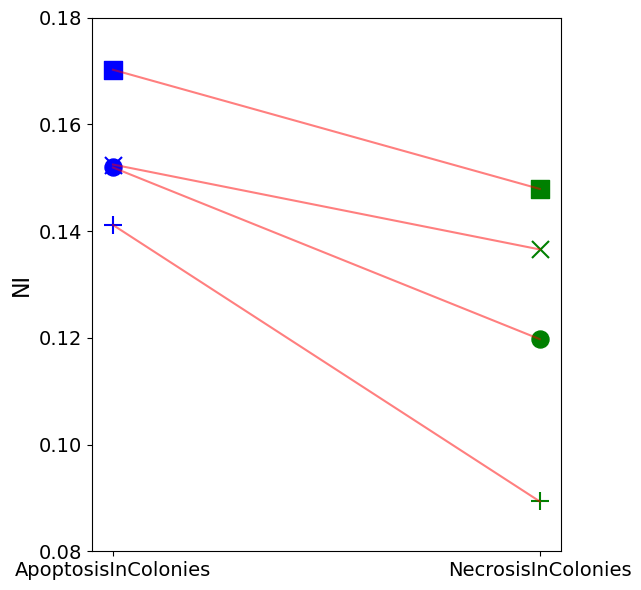

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Example data
custom_palette = {
    'ApoptosisInColonies': 'blue',
    'NecrosisInColonies': 'green'
}

# Replace treatment with origin and group values
# Filter the data for distance of 100 and sliding time window of 10
filtered_subset = filtered_df[
    (filtered_df['neighbors_dist_threshold'] == 100) &
    (filtered_df['sliding_time_window_size'] == 10)
]
origins = filtered_subset['Origin'].unique()
group_a_values = []
group_b_values = []
treatment_labels = []
markers = ['o', 'x', 's', '+']
origin_marker_dict = {origin: markers[i % len(markers)] for i, origin in enumerate(origins)}
# X positions: 0 for Group A, 1 for Group B
x_a = np.zeros(len(origins))
x_b = np.ones(len(origins))
# Assign markers based on origin
origin_markers = [origin_marker_dict[origin] for origin in origins]
for origin in origins:
    subset = filtered_subset[filtered_subset['Origin'] == origin]
    group_a = subset[subset['Treatment'] == 'ApoptosisInColonies']['NI'].values[0]
    group_b = subset[subset['Treatment'] == 'NecrosisInColonies']['NI'].values[0]
    if not np.isnan(group_a) and not np.isnan(group_b):
        group_a_values.append(group_a)
        group_b_values.append(group_b)
        treatment_labels.append(origin)  # Use treatment labels instead of origin

# Plot
plt.figure(figsize=(6.5, 6))

for i in range(len(treatment_labels)):
    # Line connecting values
    plt.plot([x_a[i], x_b[i]], [group_a_values[i], group_b_values[i]],  'r-' if group_a_values[i] > group_b_values[i] else 'k-', alpha=0.5)
    # Group A point
    plt.scatter(x_a[i], group_a_values[i], color=custom_palette['ApoptosisInColonies'], marker=origin_markers[i], label='ApoptosisInColonies' if i == 0 else "", s=150)
    # Group B point
    plt.scatter(x_b[i], group_b_values[i], color=custom_palette['NecrosisInColonies'], marker=origin_markers[i], label='NecrosisInColonies' if i == 0 else "", s=150)

custom_legend = [Line2D([0], [0], marker=marker, color='k', markerfacecolor='k', markersize=10, label=origin)
                 for origin, marker in origin_marker_dict.items()]
# Formatting
plt.xticks([0, 1], ['ApoptosisInColonies', 'NecrosisInColonies'], fontsize = 14)
plt.ylabel("NI", fontsize = 16)
plt.yticks(fontsize = 14)
# plt.title("NI Values Across Treatments")
plt.ylim(0.080, 0.180)
plt.legend(handles=custom_legend, title="Origins", loc='lower right').remove()
plt.grid(False)
plt.tight_layout()
plt.savefig("/home/esraan/CellDeathSpreading/results/NIAcrossOrigins_noLegend.svg", format="svg")
plt.show()


## segregation index

In [12]:
import os
import sys
import shutil
import math
import warnings
from typing import *
from enum import Enum
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("/home/esraan/CellDeathSpreading/")

from src.NucleationAndPropagationMeasurements import *
import seaborn as sns
from src.uSpiCalc import uSpiCalc
from src.mSpiCalc import mSpiCalc
from src.mixSpiCalc import mixSpiCalc

In [13]:

single_exp_full_paths = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/'#Field14-002_ROI#1_annotation_nec.csv'

### regular Segregation index

In [ ]:
def plot_segregation_indices(res):
    """
    Plots segregation indices for different modes across files using scatter plot.

    Parameters:
    - res: dict, dictionary containing filenames as keys and segregation indices as values
    """
    files = list(res.keys())
    modes = list(res[files[0]].keys())  # Extract modes from the first file
    mode_values = {mode: [res[file][mode][0] for file in files] for mode in modes}  # Extract first element of tuple

    markers = ['o', 'x', 's', '+', '^', 'v']  # Define markers for files
    colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown']  # Define colors for modes
    mode_color_dict = {mode: colors[i % len(colors)] for i, mode in enumerate(modes)}
    file_marker_dict = {file: markers[i % len(markers)] for i, file in enumerate(files)}

    plt.figure(figsize=(12, 6))
    for file_idx, file in enumerate(files):
        for mode in modes:
            plt.scatter(file_idx, mode_values[mode][file_idx], marker=file_marker_dict[file], color=mode_color_dict[mode], label=f"{file} - {mode}")

    plt.xticks(range(len(files)), files, rotation=45, ha='right')
    plt.title("Segregation Indices Across Files", fontsize=16)
    plt.xlabel("Files", fontsize=14)
    plt.ylabel("Segregation Index", fontsize=14)
    plt.axhline(y=1, color='red', linestyle='--', linewidth=1, label='random segregation index (1)')
    plt.legend(title="File - Mode", fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid(False)
    plt.savefig("/home/esraan/CellDeathSpreading/results/SegregationIndicesAcrossFiles.svg", format="svg")
    plt.show()

3-19-2924_10ah2bmcherry_ROI#2_annotation_nec.csv
Field14-002_ROI#1_annotation_nec.csv
20181227_MCF10A_SKT_xy3.csv
20181227_MCF10A_SKT_xy5.csv
7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_mixed.csv
{'apoptosis': (np.float64(0.9302195340501791), np.float64(0.0), np.float64(0.41680672268907565)), 'necrosis': (np.float64(0.9508885686839577), np.float64(0.0), np.float64(0.5831932773109244))}
7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_nec.csv
7-20-23_10arednuclei_ROI#10_annotation_nec.csv
Field14-002_ROI#1_annotation_apop.csv
20181227_MCF10A_SKT_xy4.csv
mixcolony2_field13.csv
Field14-002_ROI#1_annotation_mixed.csv
{'apoptosis': (np.float64(0.792894802584725), np.float64(0.0), np.float64(0.6056338028169014)), 'necrosis': (np.float64(0.6813428316440363), np.float64(0.0), np.float64(0.38967136150234744)), 'mix': (np.float64(0.0), np.float64(0.0), np.float64(0.001564945226917058)), 'entosis': (np.float64(0.19642857142857142), np.float64(0.001), np.float64(0.0031298904

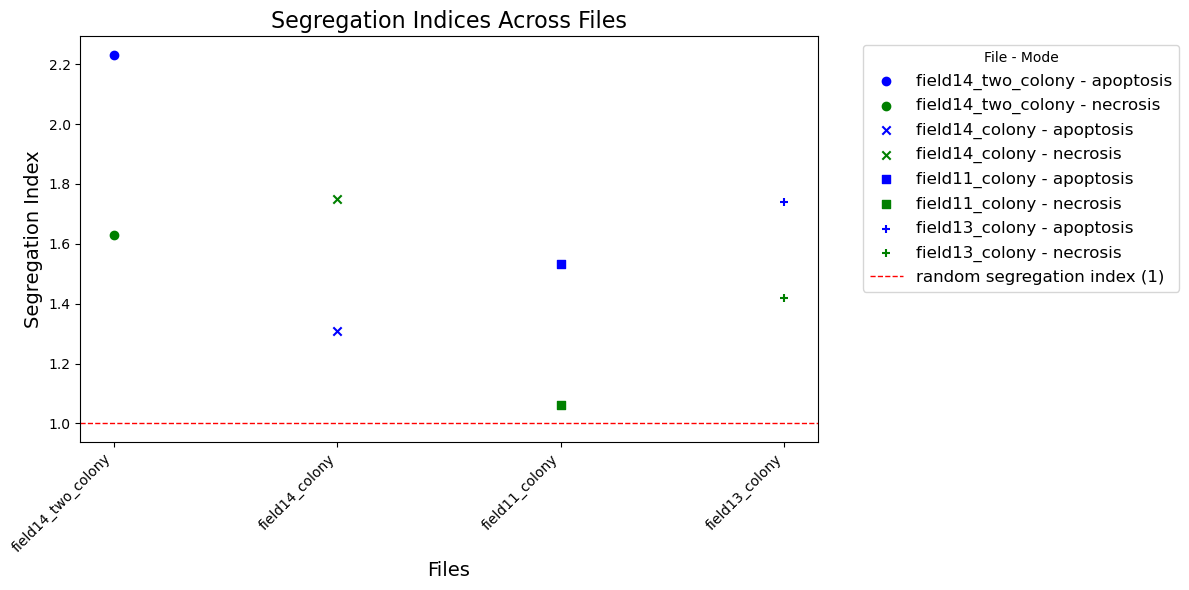

In [15]:

import os  # Ensure os module is imported

# single_exp_full_paths = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/csv_files_minutes_microns_sytox/'
res = {}
for idx, file in enumerate(os.listdir(single_exp_full_paths)):
    print(file)
    if '_mixed' not in file:
        continue
    cells_loci, cells_times_of_death = read_experiment_cell_xy_and_death_times(exp_full_path=os.path.join(single_exp_full_paths, file))
    exp_full_path = os.path.join(single_exp_full_paths, file)
    csv_file = pd.read_csv(exp_full_path)
    dist_threshold = 100
    death_modes = csv_file[["Mode"]].values
    segregation_index = SegregationIdx(cells_loci, death_modes, 1000, dist_threshold, filter_neighbors_by_distance=True, neighbors_level=1, stats_to_calculate="mean")
    seg_res_dict = segregation_index.get_segregation_index()
    distr_dict = segregation_index.permuted_si
    print(seg_res_dict)
    res[file] = {key: ((value[0] / value[2]), value[1]) for key, value in seg_res_dict.items() if key in ('apoptosis', 'necrosis')}

new_res = {
    '7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_mixed.csv': 'field14_two_colony',
    'Field14-002_ROI#1_annotation_mixed.csv': 'field14_colony',
    '7-20-23_10arednuclei_ROI#10_annotation_mixed.csv': "field11_colony",
    'field13_crop-001_ROI#1_annotation_mixed.csv': 'field13_colony'
}
plot_res_dict = {new_res.get(key, key): value for key, value in res.items()}  # Provide default key if not found

import matplotlib.pyplot as plt



# Example usage

plot_segregation_indices(plot_res_dict)

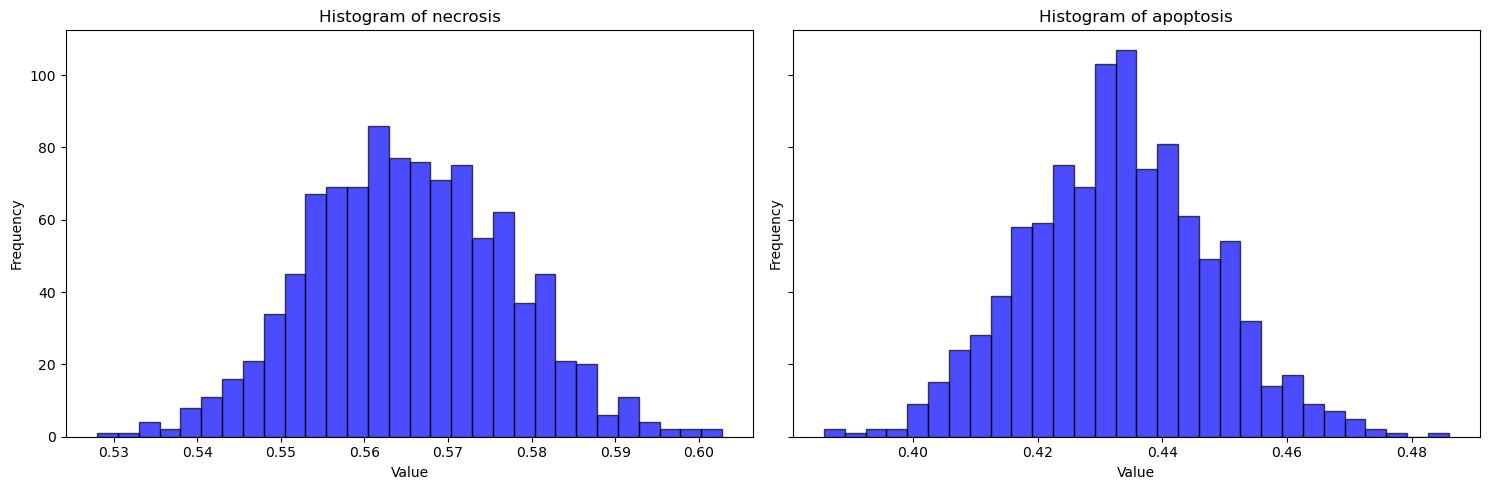

In [16]:
# Create subplots for each key in distr_dict
fig, axes = plt.subplots(nrows=1, ncols=len(distr_dict), figsize=(15, 5), sharey=True)

# Iterate over each key and its corresponding values in distr_dict
for ax, (key, values) in zip(axes, distr_dict.items()):
    ax.hist(values, bins=30, alpha=0.7, color='blue', edgecolor='black')
    ax.set_title(f"Histogram of {key}")
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

# Adjust layout for better visualization
plt.tight_layout()
plt.show()

### PAPER SI

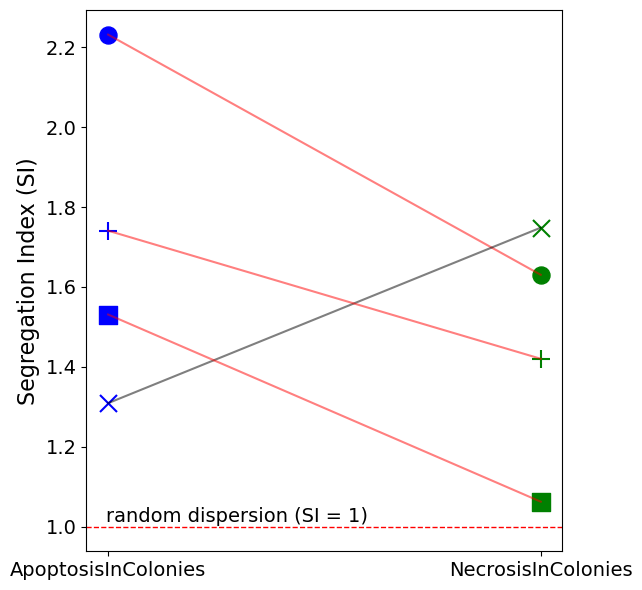

In [42]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
# Example data
custom_palette = {
    'ApoptosisInColonies': 'blue',
    'NecrosisInColonies': 'green'
}
# Extract origins and corresponding values from plot_res_dict
origins = list(plot_res_dict.keys())
group_a_values = []
group_b_values = []
markers = ['o', 'x', 's', '+']
origin_marker_dict = {origin: markers[i % len(markers)] for i, origin in enumerate(origins)}

# Assign markers based on origin
origin_markers = [origin_marker_dict[origin] for origin in origins]
for origin, values in plot_res_dict.items():
    group_a = values.get('apoptosis', (np.nan,))[0]  # Get the first value for 'apoptosis'
    marker = origin_marker_dict[origin]  # Assign marker based on origin
    group_b = values.get('necrosis', (np.nan,))[0]   # Get the first value for 'necrosis'
    if not np.isnan(group_a) and not np.isnan(group_b):
        group_a_values.append(group_a)
        group_b_values.append(group_b)

# X positions: 0 for Group A, 1 for Group B
x_a = np.zeros(len(origins))
x_b = np.ones(len(origins))

# Plot
plt.figure(figsize=(6.5, 6))

for i in range(len(origins)):
    # Line connecting values 'r-' if group_a_values[i] < group_b_values[i]
    plt.plot([x_a[i], x_b[i]], [group_a_values[i], group_b_values[i]], 'r-' if group_a_values[i] > group_b_values[i] else 'k-', alpha=0.5)
    # Group A point
    plt.scatter(x_a[i], group_a_values[i], color=custom_palette['ApoptosisInColonies'], marker=origin_markers[i], label='ApoptosisInColonies' if i == 0 else "", s=150)
    # Group B point
    plt.scatter(x_b[i], group_b_values[i], color=custom_palette['NecrosisInColonies'], marker=origin_markers[i], label='NecrosisInColonies' if i == 0 else "", s=150)

# Create custom legend entries for markers
custom_legend = [Line2D([0], [0], marker=marker, color='k', markerfacecolor='k', markersize=10, label=origin)
                 for origin, marker in origin_marker_dict.items()]

plt.axhline(y=1, color='red', linestyle='--', linewidth=1,)
plt.text(0.60, 1.025, 'random dispersion (SI = 1)', color='black', fontsize=14, va='center', ha='right')
# Formatting
plt.xticks([0, 1], ['ApoptosisInColonies', 'NecrosisInColonies'], fontsize = 14)
plt.yticks(fontsize = 14)
plt.ylabel("Segregation Index (SI)", fontsize = 16)
# plt.title("Segregation Index Across Origins")
plt.legend(handles=custom_legend, title="Origins", loc='upper right').remove()
plt.grid(False)
plt.tight_layout()
plt.savefig("/home/esraan/CellDeathSpreading/results/SegregationIndexAcrossOrigins_noLegend.svg", format="svg")
plt.show()


### no LINE of perfecty SI

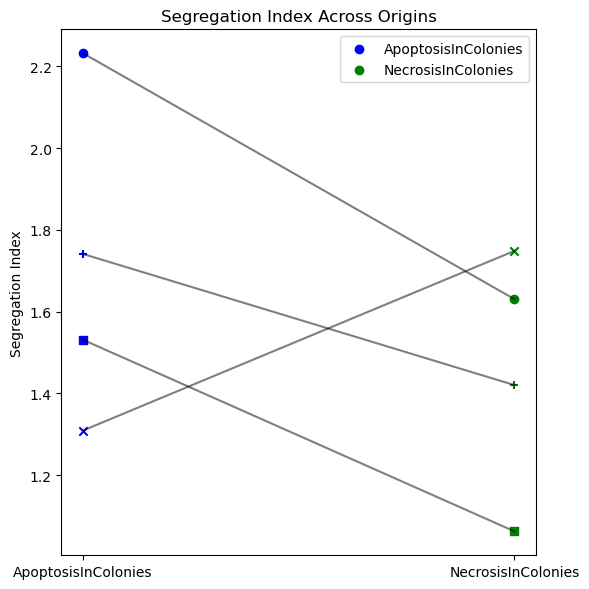

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Extract origins and corresponding values from plot_res_dict
origins = list(plot_res_dict.keys())
group_a_values = []
group_b_values = []
markers = ['o', 'x', 's', '+']
origin_marker_dict = {origin: markers[i % len(markers)] for i, origin in enumerate(origins)}

# Assign markers based on origin
origin_markers = [origin_marker_dict[origin] for origin in origins]
for origin, values in plot_res_dict.items():
    group_a = values.get('apoptosis', (np.nan,))[0]  # Get the first value for 'apoptosis'
    marker = origin_marker_dict[origin]  # Assign marker based on origin
    group_b = values.get('necrosis', (np.nan,))[0]   # Get the first value for 'necrosis'
    if not np.isnan(group_a) and not np.isnan(group_b):
        group_a_values.append(group_a)
        group_b_values.append(group_b)

# X positions: 0 for Group A, 1 for Group B
x_a = np.zeros(len(origins))
x_b = np.ones(len(origins))

# Plot
plt.figure(figsize=(6, 6))

for i in range(len(origins)):
    # Line connecting values
    plt.plot([x_a[i], x_b[i]], [group_a_values[i], group_b_values[i]], 'k-', alpha=0.5)
    # Group A point
    plt.scatter(x_a[i], group_a_values[i], color=custom_palette['ApoptosisInColonies'], marker=origin_markers[i], label='ApoptosisInColonies' if i == 0 else "")
    # Group B point
    plt.scatter(x_b[i], group_b_values[i], color=custom_palette['NecrosisInColonies'], marker=origin_markers[i], label='NecrosisInColonies' if i == 0 else "")
    # Origin label on the left
    # plt.text(-0.1, group_a_values[i], origins[i], va='center', ha='right', fontsize=9)

# Formatting
plt.xticks([0, 1], ['ApoptosisInColonies', 'NecrosisInColonies'])
plt.ylabel("Segregation Index")
plt.title("Segregation Index Across Origins")
plt.legend()#.remove()
plt.grid(False)
plt.tight_layout()
plt.show()


In [8]:
new_res = {'7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_mixed.csv': 'field14_two_colony',
'Field14-002_ROI#1_annotation_mixed.csv': 'field14_colony',
'7-20-23_10arednuclei_ROI#10_annotation_mixed.csv': "field11_colony",
'field13_crop-001_ROI#1_annotation_mixed.csv': 'field13_colony'}
plot_res_dict = {new_res.get(key):value for key,value in res.items()}

In [9]:
plot_res_dict

{'field14_two_colony': {'apoptosis': (np.float64(2.231776704676841),
   np.float64(0.0)),
  'necrosis': (np.float64(1.6304861624407918), np.float64(0.0))},
 'field14_colony': {'apoptosis': (np.float64(1.3091983949654762),
   np.float64(0.0)),
  'necrosis': (np.float64(1.7485063028937315), np.float64(0.0))},
 'field11_colony': {'apoptosis': (np.float64(1.531100045269353),
   np.float64(0.0)),
  'necrosis': (np.float64(1.0625830688355484), np.float64(0.0))},
 'field13_colony': {'necrosis': (np.float64(1.4203113708486506),
   np.float64(0.0)),
  'apoptosis': (np.float64(1.740928566765772), np.float64(0.0))}}

### SA in Segregation index

In [25]:

single_exp_full_paths = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/'#Field14-002_ROI#1_annotation_nec.csv'
new_res = {'7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_mixed.csv': 'field14_two_colony',
'Field14-002_ROI#1_annotation_mixed.csv': 'field14_colony',
'7-20-23_10arednuclei_ROI#10_annotation_mixed.csv': "field11_colony",
'field13_crop-001_ROI#1_annotation_mixed.csv': 'field13_colony'}
# Define the distances to iterate over
distances = [33, 50, 100, 150, 200]
custom_palette = {
    'apoptosis': 'blue',
    'necrosis': 'green'
}
# Initialize a dictionary to store results for each distance
results_by_distance = {}

# Iterate over each distance
for dist in distances:
    res = {}
    for idx, file in enumerate(os.listdir(single_exp_full_paths)):
        if '_mixed' not in file:
            continue
        cells_loci, cells_times_of_death = read_experiment_cell_xy_and_death_times(
            exp_full_path=os.path.join(single_exp_full_paths, file)
        )
        exp_full_path = os.path.join(single_exp_full_paths, file)
        csv_file = pd.read_csv(exp_full_path)
        death_modes = csv_file[["Mode"]].values
        segregation_index = SegregationIdx(
            cells_loci, death_modes, 1000, dist, filter_neighbors_by_distance=True, neighbors_level=1, stats_to_calculate="mean"
        )
        seg_res_dict = segregation_index.get_segregation_index()
        res[file] = {key: (value[0] / value[2], value[1]) for key, value in seg_res_dict.items() if key in ('apoptosis', 'necrosis')}
    
    # Map file names to new_res dictionary
    plot_res_dict = {new_res.get(key): value for key, value in res.items()}
    results_by_distance[dist] = plot_res_dict

# # Plot results for each distance in subplots
# fig, axes = plt.subplots(nrows=1, ncols=len(distances), figsize=(20, 5), sharey=True)

# for i, dist in enumerate(distances):
#     ax = axes[i]
#     res = results_by_distance[dist]
#     files = list(res.keys())
#     modes = list(res[files[0]].keys())
#     mode_values = {mode: [res[file][mode] for file in files] for mode in modes}

#     markers = ['o', 'x', 's', '+', '^', 'v']
#     # colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown']
#     # mode_color_dict = 
#     file_marker_dict = {file: markers[i % len(markers)] for i, file in enumerate(files)}

#     for file_idx, file in enumerate(files):
#         for mode in modes:
#             ax.scatter(file_idx, res[file][mode], marker=file_marker_dict[file], color=custom_palette.get(mode, 'black'))#, label=f"{file} - {mode}" if file_idx == 0 else "")

#     ax.set_xticks(range(len(files)))
#     ax.set_xticklabels(files, rotation=45, ha='right', fontsize=8)
#     ax.set_title(f"Distance: {dist}", fontsize=12)
#     ax.axhline(y=1, color='red', linestyle='--', linewidth=1)
#     ax.grid(False)

# fig.suptitle("Segregation Indices Across Distances", fontsize=16)
# fig.tight_layout(rect=[0, 0, 1, 0.95])
# fig.legend(title="File - Mode", fontsize=10, bbox_to_anchor=(1.05, 0.5), loc='center left')
# plt.show()


In [ ]:

single_exp_full_paths = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/'#Field14-002_ROI#1_annotation_nec.csv'
new_res = {'7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_mixed.csv': 'field14_two_colony',
'Field14-002_ROI#1_annotation_mixed.csv': 'field14_colony',
'7-20-23_10arednuclei_ROI#10_annotation_mixed.csv': "field11_colony",
'field13_crop-001_ROI#1_annotation_mixed.csv': 'field13_colony'}
# Define the distances to iterate over
distances = [33, 50, 100, 150, 200]
custom_palette = {
    'apoptosis': 'blue',
    'necrosis': 'green'
}
# Initialize a dictionary to store results for each distance
results_by_distance = {}

# Iterate over each distance
for dist in distances:
    res = {}
    for idx, file in enumerate(os.listdir(single_exp_full_paths)):
        if '_mixed' not in file:
            continue
        cells_loci, cells_times_of_death = read_experiment_cell_xy_and_death_times(
            exp_full_path=os.path.join(single_exp_full_paths, file)
        )
        exp_full_path = os.path.join(single_exp_full_paths, file)
        csv_file = pd.read_csv(exp_full_path)
        death_modes = csv_file[["Mode"]].values
        segregation_index = SegregationIdx(
            cells_loci, death_modes, 1000, dist, filter_neighbors_by_distance=True, neighbors_level=1, stats_to_calculate="mean"
        )
        seg_res_dict = segregation_index.get_segregation_index()
        res[file] = {key: (value[0] / value[2], value[1]) for key, value in seg_res_dict.items() if key in ('apoptosis', 'necrosis')}
    
    # Map file names to new_res dictionary
    plot_res_dict = {new_res.get(key): value for key, value in res.items()}
    results_by_distance[dist] = plot_res_dict
# Plot results for each distance in subplots
fig, axes = plt.subplots(nrows=1, ncols=len(distances), figsize=(20, 5), sharey=True)

for i, dist in enumerate(distances):
    ax = axes[i]
    res = results_by_distance[dist]
    files = list(res.keys())
    modes = list(res[files[0]].keys())
    mode_values = {mode: [res[file][mode] for file in files] for mode in modes}

    markers = ['o', 'x', 's', '+', '^', 'v']
    # colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown']
    # mode_color_dict = 
    file_marker_dict = {file: markers[i % len(markers)] for i, file in enumerate(files)}

    for file_idx, file in enumerate(files):
        for mode in modes:
            # Extract the scalar value for y (first element of the tuple)
            y_value = res[file][mode][0] if isinstance(res[file][mode], tuple) else res[file][mode]
            ax.scatter(file_idx, y_value, marker=file_marker_dict[file], color=custom_palette.get(mode, 'black'))  # Ensure y_value is scalar

    ax.set_xticks(range(len(files)))
    ax.set_xticklabels(files, rotation=45, ha='right', fontsize=8)
    ax.set_title(f"Distance: {dist}", fontsize=12)
    ax.axhline(y=1, color='red', linestyle='--', linewidth=1)
    ax.grid(False)

fig.suptitle("Segregation Indices Across Distances", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.legend(title="File - Mode", fontsize=10, bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.show()

/tmp/ipykernel_2123842/3908808356.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(title="File - Mode", fontsize=10, bbox_to_anchor=(1.05, 0.5), loc='center left')


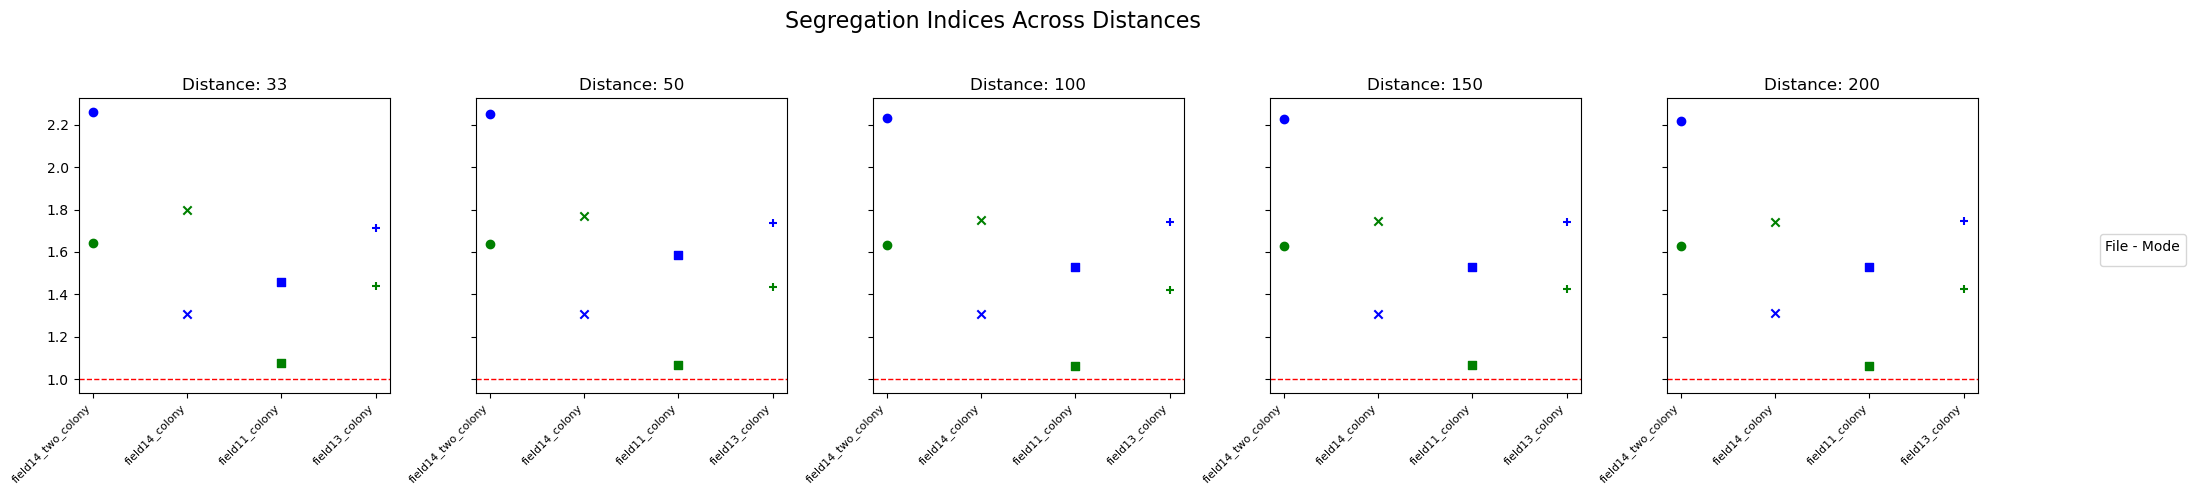

In [24]:

single_exp_full_paths = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/'#Field14-002_ROI#1_annotation_nec.csv'
new_res = {'7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_mixed.csv': 'field14_two_colony',
'Field14-002_ROI#1_annotation_mixed.csv': 'field14_colony',
'7-20-23_10arednuclei_ROI#10_annotation_mixed.csv': "field11_colony",
'field13_crop-001_ROI#1_annotation_mixed.csv': 'field13_colony'}
# Define the distances to iterate over
distances = [33, 50, 100, 150, 200]
custom_palette = {
    'apoptosis': 'blue',
    'necrosis': 'green'
}
# Initialize a dictionary to store results for each distance
results_by_distance = {}

# Iterate over each distance
for dist in distances:
    res = {}
    for idx, file in enumerate(os.listdir(single_exp_full_paths)):
        if '_mixed' not in file:
            continue
        cells_loci, cells_times_of_death = read_experiment_cell_xy_and_death_times(
            exp_full_path=os.path.join(single_exp_full_paths, file)
        )
        exp_full_path = os.path.join(single_exp_full_paths, file)
        csv_file = pd.read_csv(exp_full_path)
        death_modes = csv_file[["Mode"]].values
        segregation_index = SegregationIdx(
            cells_loci, death_modes, 1000, dist, filter_neighbors_by_distance=True, neighbors_level=1, stats_to_calculate="mean"
        )
        seg_res_dict = segregation_index.get_segregation_index()
        res[file] = {key: (value[0] / value[2], value[1]) for key, value in seg_res_dict.items() if key in ('apoptosis', 'necrosis')}
    
    # Map file names to new_res dictionary
    plot_res_dict = {new_res.get(key): value for key, value in res.items()}
    results_by_distance[dist] = plot_res_dict
# Plot results for each distance in subplots
fig, axes = plt.subplots(nrows=1, ncols=len(distances), figsize=(20, 5), sharey=True)

for i, dist in enumerate(distances):
    ax = axes[i]
    res = results_by_distance[dist]
    files = list(res.keys())
    modes = list(res[files[0]].keys())
    mode_values = {mode: [res[file][mode] for file in files] for mode in modes}

    markers = ['o', 'x', 's', '+', '^', 'v']
    # colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown']
    # mode_color_dict = 
    file_marker_dict = {file: markers[i % len(markers)] for i, file in enumerate(files)}

    for file_idx, file in enumerate(files):
        for mode in modes:
            # Extract the scalar value for y (first element of the tuple)
            y_value = res[file][mode][0] if isinstance(res[file][mode], tuple) else res[file][mode]
            ax.scatter(file_idx, y_value, marker=file_marker_dict[file], color=custom_palette.get(mode, 'black'))  # Ensure y_value is scalar

    ax.set_xticks(range(len(files)))
    ax.set_xticklabels(files, rotation=45, ha='right', fontsize=8)
    ax.set_title(f"Distance: {dist}", fontsize=12)
    ax.axhline(y=1, color='red', linestyle='--', linewidth=1)
    ax.grid(False)

fig.suptitle("Segregation Indices Across Distances", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.legend(title="File - Mode", fontsize=10, bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.show()

/tmp/ipykernel_2123842/1875366834.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(title="File - Mode", fontsize=10, bbox_to_anchor=(1.05, 0.5), loc='center left')


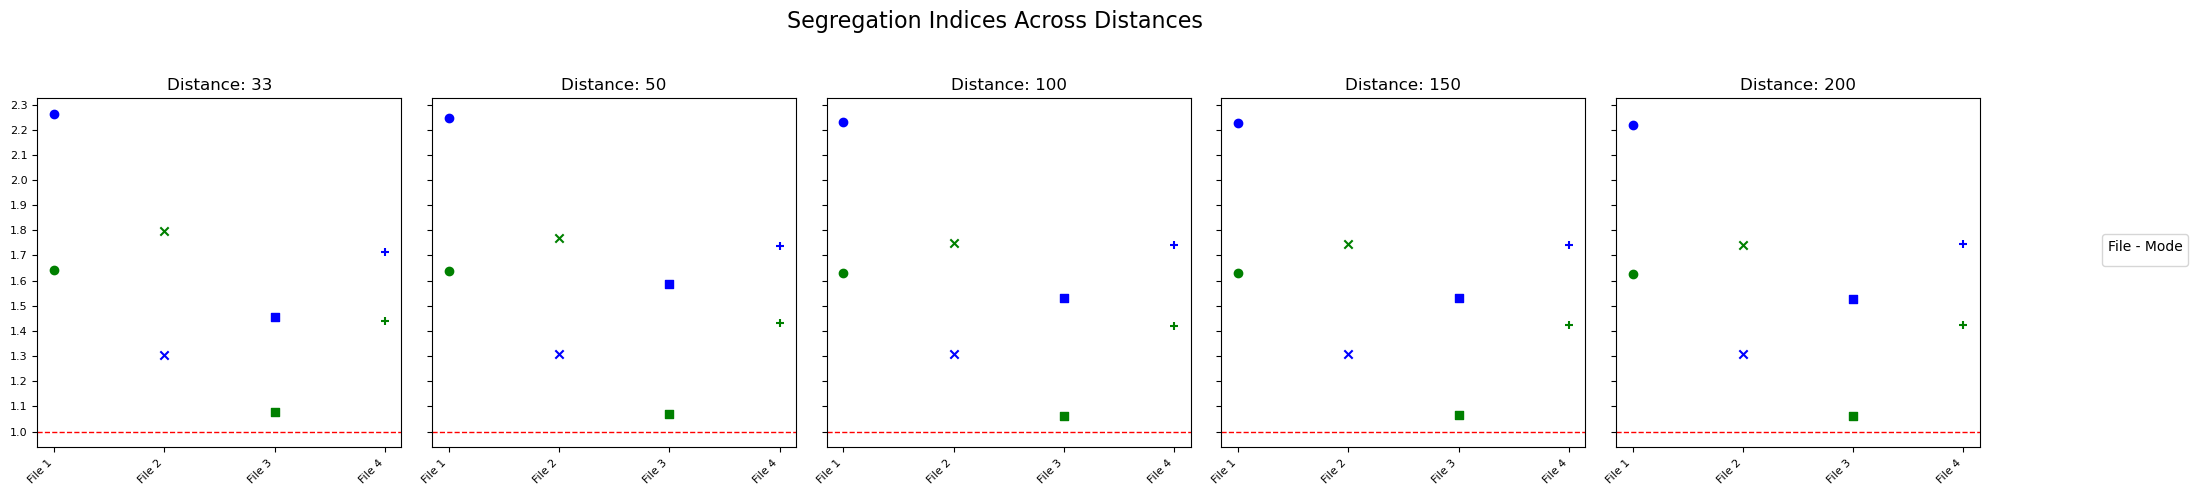

In [20]:
# Plot results for each distance in subplots
fig, axes = plt.subplots(nrows=1, ncols=len(distances), figsize=(20, 5), sharey=True)

for i, dist in enumerate(distances):
    ax = axes[i]
    res = results_by_distance[dist]
    files = list(res.keys())
    modes = list(res[files[0]].keys())
    mode_values = {mode: [res[file][mode] for file in files] for mode in modes}

    markers = ['o', 'x', 's', '+', '^', 'v']
    file_marker_dict = {file: markers[i % len(markers)] for i, file in enumerate(files)}

    for file_idx, file in enumerate(files):
        for mode in modes:
            # Extract the scalar value for y (first element of the tuple)
            y_value = res[file][mode][0] if isinstance(res[file][mode], tuple) else res[file][mode]
            ax.scatter(file_idx, y_value, marker=file_marker_dict[file], color=custom_palette.get(mode, 'black'))  # Ensure y_value is scalar

    # Add more ticks and replace axis contents
    ax.set_xticks(range(len(files)))
    ax.set_xticklabels([f"File {idx+1}" for idx in range(len(files))], rotation=45, ha='right', fontsize=8)
    ax.set_yticks([1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0,2.1,2.2,2.3])
    ax.set_yticklabels([f"{tick:.1f}" for tick in [1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0,2.1,2.2,2.3]], fontsize=8)

    ax.set_title(f"Distance: {dist}", fontsize=12)
    ax.axhline(y=1, color='red', linestyle='--', linewidth=1)
    ax.grid(False)

fig.suptitle("Segregation Indices Across Distances", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.legend(title="File - Mode", fontsize=10, bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.show()


In [16]:
# Convert the res dictionary into a DataFrame
# Flatten the results_by_distance dictionary into a DataFrame
results_flat = {
    (distance, file, mode): values[0]
    for distance, files in results_by_distance.items()
    for file, modes in files.items()
    for mode, values in modes.items()
}

# Convert the flattened dictionary into a DataFrame
res_df = pd.DataFrame.from_dict(results_flat, orient='index', columns=['SegregationIndex'])

# Reset the index to make it more readable
res_df.index = pd.MultiIndex.from_tuples(res_df.index, names=["Distance", "File", "Mode"])
res_df.reset_index(inplace=True)

# Display the resulting DataFrame
print(res_df)
res_df.to_csv("/home/esraan/CellDeathSpreading/results/SegregationIndicesByDistance.csv", index=False)

    Distance                File       Mode  SegregationIndex
0         33  field14_two_colony  apoptosis          2.261463
1         33  field14_two_colony   necrosis          1.643763
2         33      field14_colony  apoptosis          1.305017
3         33      field14_colony   necrosis          1.797183
4         33      field11_colony  apoptosis          1.455930
5         33      field11_colony   necrosis          1.076661
6         33      field13_colony   necrosis          1.439822
7         33      field13_colony  apoptosis          1.714494
8         50  field14_two_colony  apoptosis          2.248334
9         50  field14_two_colony   necrosis          1.638175
10        50      field14_colony  apoptosis          1.306559
11        50      field14_colony   necrosis          1.767536
12        50      field11_colony  apoptosis          1.585899
13        50      field11_colony   necrosis          1.068441
14        50      field13_colony   necrosis          1.432592
15      

In [ ]:
# Convert the res dictionary into a DataFrame
# Flatten the results_by_distance dictionary into a DataFrame
results_flat = {
    (distance, file, mode): values[0]
    for distance, files in results_by_distance.items()
    for file, modes in files.items()
    for mode, values in modes.items()
}

# Convert the flattened dictionary into a DataFrame
res_df = pd.DataFrame.from_dict(results_flat, orient='index', columns=['SegregationIndex'])

# Reset the index to make it more readable
res_df.index = pd.MultiIndex.from_tuples(res_df.index, names=["Distance", "File", "Mode"])
res_df.reset_index(inplace=True)

# Display the resulting DataFrame
print(res_df)
# res_df = pd.DataFrame.from_dict({(file, mode): values[0] for file, modes in res.items() for mode, values in modes.items()}, orient='index', columns=['SegregationIndex'])

# # Reset the index to make it more readable
# res_df.index = pd.MultiIndex.from_tuples(res_df.index, names=["File", "Mode"])
# res_df.reset_index(inplace=True)

# # Display the resulting DataFrame
# print(res_df)

                 File       Mode  SegregationIndex
0  field14_two_colony  apoptosis          2.219085
1  field14_two_colony   necrosis          1.626192
2      field14_colony  apoptosis          1.310033
3      field14_colony   necrosis          1.742691
4      field11_colony  apoptosis          1.527026
5      field11_colony   necrosis          1.063833
6      field13_colony   necrosis          1.422898
7      field13_colony  apoptosis          1.745881


/tmp/ipykernel_1225859/727173049.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(title="File - Mode", fontsize=10, bbox_to_anchor=(1.05, 0.5), loc='center left')


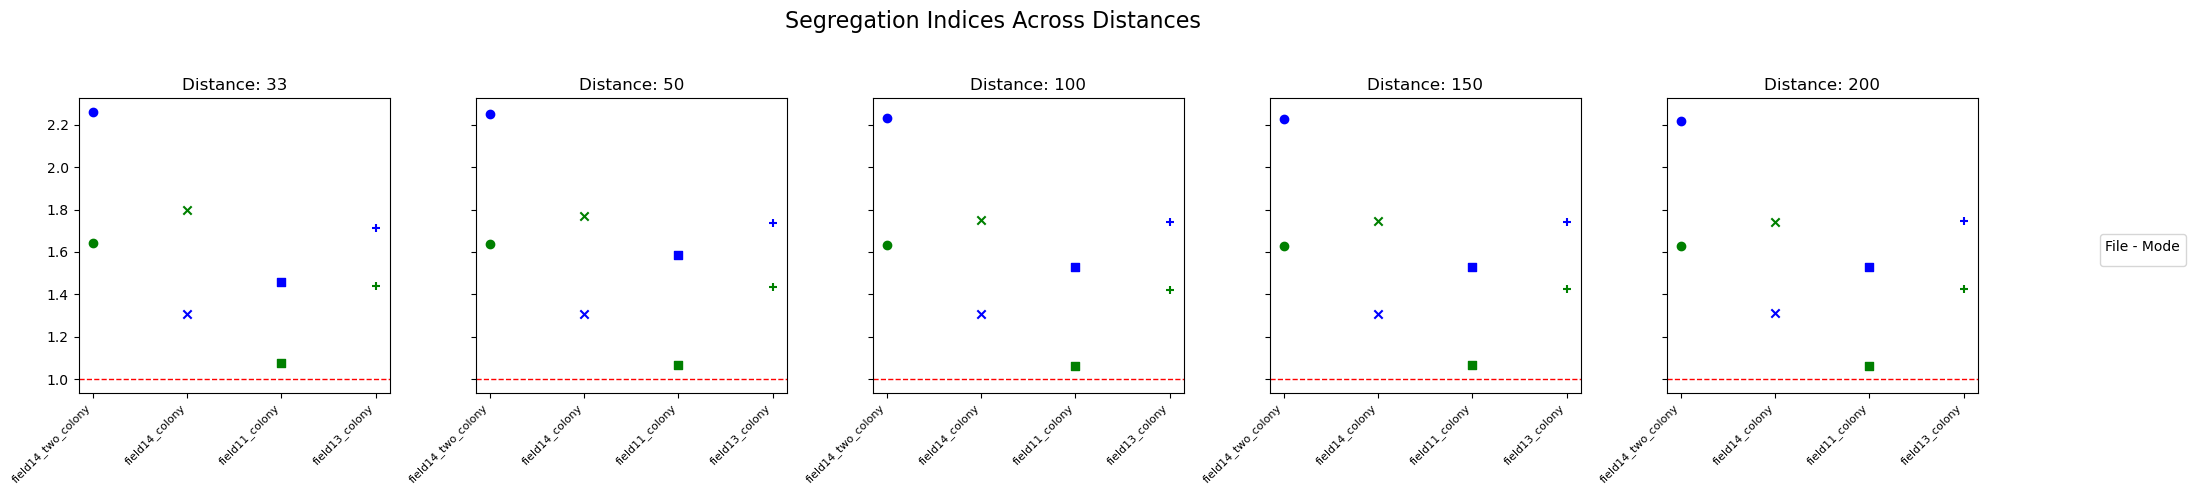

In [24]:
# Plot results for each distance in subplots
fig, axes = plt.subplots(nrows=1, ncols=len(distances), figsize=(20, 5), sharey=True)

for i, dist in enumerate(distances):
    ax = axes[i]
    res = results_by_distance[dist]
    files = list(res.keys())
    modes = list(res[files[0]].keys())
    mode_values = {mode: [res[file][mode] for file in files] for mode in modes}

    markers = ['o', 'x', 's', '+', '^', 'v']
    # colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown']
    # mode_color_dict = 
    file_marker_dict = {file: markers[i % len(markers)] for i, file in enumerate(files)}

    for file_idx, file in enumerate(files):
        for mode in modes:
            # Extract the scalar value for y (first element of the tuple)
            y_value = res[file][mode][0] if isinstance(res[file][mode], tuple) else res[file][mode]
            ax.scatter(file_idx, y_value, marker=file_marker_dict[file], color=custom_palette.get(mode, 'black'))  # Ensure y_value is scalar

    ax.set_xticks(range(len(files)))
    ax.set_xticklabels(files, rotation=45, ha='right', fontsize=8)
    ax.set_title(f"Distance: {dist}", fontsize=12)
    ax.axhline(y=1, color='red', linestyle='--', linewidth=1)
    ax.grid(False)

fig.suptitle("Segregation Indices Across Distances", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.legend(title="File - Mode", fontsize=10, bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.show()